# Model Prediction Analysis for Arrythmia and Heart Damage of Cadiac Organoids

This notebook trains XGBoost models using **only** the PK-PD elimination equation coefficients to predict:
- **Arrhythmia** (binary: true/false)
- **Heart Damage** (binary: true/false)  
- **Concern** (multiclass: most/less/no)

Each step is shown in separate cells so you can validate the data as we go.


## Installation Instructions

**If you get import errors, run the cell below to install all required packages.**

Alternatively, you can install from the command line:
```bash
pip install pandas numpy scikit-learn xgboost joblib openpyxl matplotlib ipykernel jupyter
```


In [1]:
# Install required packages (run this cell first if you get import errors)
# Uncomment the line below and run this cell to install all dependencies

# !pip install pandas numpy scikit-learn xgboost joblib openpyxl matplotlib ipykernel

# Or install all at once:
# !pip install pandas numpy scikit-learn xgboost joblib openpyxl matplotlib ipykernel jupyter

print("If you see import errors, uncomment the pip install line above and run this cell.")
print("Required packages:")
print("  - pandas (for data manipulation)")
print("  - numpy (for numerical operations)")
print("  - scikit-learn (for machine learning)")
print("  - xgboost (for XGBoost models)")
print("  - joblib (for saving models)")
print("  - openpyxl (for reading Excel files)")
print("  - matplotlib (for plotting, optional)")
print("  - ipykernel (for Jupyter notebook support)")


If you see import errors, uncomment the pip install line above and run this cell.
Required packages:
  - pandas (for data manipulation)
  - numpy (for numerical operations)
  - scikit-learn (for machine learning)
  - xgboost (for XGBoost models)
  - joblib (for saving models)
  - openpyxl (for reading Excel files)
  - matplotlib (for plotting, optional)
  - ipykernel (for Jupyter notebook support)


In [2]:
# Dependencies: None (initial setup cell)
# Cell 1: Imports and Setup
import pandas as pd
import numpy as np
import sys
import os
import random
from pathlib import Path
import seaborn as sns

# Configure matplotlib to use Helvetica font at size 14
import matplotlib as mpl
from matplotlib import font_manager
import matplotlib.pyplot as plt

# Locate fonts whether you run from repo root or inside Prediction_Models
cwd = Path.cwd()
fonts_dir = (cwd / "fonts") if (cwd / "fonts").exists() else (cwd.parent / "fonts")

font_manager.fontManager.addfont(str(fonts_dir / "helvetica.ttf"))
font_manager.fontManager.addfont(str(fonts_dir / "helvetica-bold.ttf"))

mpl.rcParams.update({
    "font.family": "Helvetica",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.weight": "normal",
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.titlesize": 14,
})

print(f"Font configured: {mpl.rcParams['font.family']}")
print(f"Font size: {mpl.rcParams['font.size']}")

# Find project root - look for EQN_Coefficients directory (current workspace structure)
current_dir = Path.cwd()

# Strategy 1: Check if we're in Prediction_Models directory
if current_dir.name == 'Prediction_Models':
    PROJECT_ROOT = current_dir.parent
# Strategy 2: Check if EQN_Coefficients exists in current directory
elif (current_dir / 'EQN_Coefficients').exists():
    PROJECT_ROOT = current_dir
# Strategy 3: Check if EQN_Coefficients exists one level up
elif (current_dir.parent / 'EQN_Coefficients').exists():
    PROJECT_ROOT = current_dir.parent
# Strategy 4: Check if we're in a subdirectory and need to go up
elif (current_dir.parent.parent / 'EQN_Coefficients').exists():
    PROJECT_ROOT = current_dir.parent.parent
else:
    # Default: assume current directory is project root
    PROJECT_ROOT = current_dir

# Add Prediction_Models to path for utils import
prediction_models_dir = PROJECT_ROOT / 'Prediction_Models'
if prediction_models_dir.exists():
    sys.path.insert(0, str(prediction_models_dir))

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("Warning: XGBoost not available. Install with: pip install xgboost")

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score
from sklearn.svm import SVC  # For Gaussian Kernel (Heart Damage)
from sklearn.linear_model import LogisticRegression  # For Concern
from sklearn.ensemble import RandomForestClassifier  # For Random Forest

# Import utility functions
from utils import preprocess_targets, extract_features

# Set pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 30)

# Define paths relative to project root
EXCEL_PATH = PROJECT_ROOT / 'EQN_Coefficients' / 'all_equations_coefficients.xlsx'
DEFAULT_EQUATION_NAME = 'pkpd_elimination'

if EXCEL_PATH.exists():
    try:
        available_sheets = pd.ExcelFile(EXCEL_PATH).sheet_names
    except Exception as e:
        available_sheets = []
        print(f"Warning: unable to read sheet names: {e}")
else:
    available_sheets = []

if DEFAULT_EQUATION_NAME in available_sheets:
    EQUATION_NAME = DEFAULT_EQUATION_NAME
elif available_sheets:
    EQUATION_NAME = available_sheets[0]
    print(f"Warning: '{DEFAULT_EQUATION_NAME}' not found. Using '{EQUATION_NAME}' instead.")
else:
    EQUATION_NAME = DEFAULT_EQUATION_NAME

print("Setup complete!")
print(f"Project root: {PROJECT_ROOT}")
print(f"Current working directory: {Path.cwd()}")
print(f"XGBoost available: {XGBOOST_AVAILABLE}")
print(f"Excel path: {EXCEL_PATH}")
print(f"Excel file exists: {EXCEL_PATH.exists()}")
print(f"Equation: {EQUATION_NAME}")

# Verify Excel file exists
if not EXCEL_PATH.exists():
    print(f"\n⚠️  WARNING: Excel file not found at {EXCEL_PATH}")
    print("Please check that the file exists or update the path.")
else:
    print("✓ Excel file found!")


Font configured: ['Helvetica']
Font size: 14.0
Setup complete!
Project root: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO
Current working directory: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Prediction_Models
XGBoost available: True
Excel path: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\EQN_Coefficients\all_equations_coefficients.xlsx
Excel file exists: True
Equation: pkpd_elimination
✓ Excel file found!


## Step 1: Load Raw PK-PD Elimination Data

Load the PK-PD elimination equation sheet from the Excel file. This contains coefficient data for both Contractility and O2 responses.


In [3]:
# Cell 2: Load Raw PK-PD Elimination Data
print("="*80)
print("LOADING RAW PK-PD ELIMINATION DATA")
print("="*80)

# Read Excel sheet - skip first row (header with Contractility/O2 labels)
# Column names are in row 1 (0-indexed)
df_raw = pd.read_excel(EXCEL_PATH, sheet_name=EQUATION_NAME, header=1)

# Clean column names (remove whitespace)
df_raw.columns = df_raw.columns.str.strip()

# Remove rows where Drug is missing or empty
initial_rows = len(df_raw)
df_raw = df_raw[df_raw['Drug'].notna() & (df_raw['Drug'].astype(str).str.strip() != '')]

print(f"\nLoaded data from: {EXCEL_PATH}")
print(f"Sheet name: {EQUATION_NAME}")
print(f"Initial rows: {initial_rows}")
print(f"Rows after filtering: {len(df_raw)}")
print(f"Columns: {len(df_raw.columns)}")
print(f"\nColumn names:")
print(df_raw.columns.tolist())


LOADING RAW PK-PD ELIMINATION DATA

Loaded data from: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\EQN_Coefficients\all_equations_coefficients.xlsx
Sheet name: pkpd_elimination
Initial rows: 25
Rows after filtering: 25
Columns: 24

Column names:
['Drug', 'Arrhythmia', 'heart_damage', 'Concern', 'R0', 'Emax', 'kappa', 'n', 'm', 'tau', 'k_elim', 'Cmax_used', 'R2', 'N_points', 'R0.1', 'Emax.1', 'kappa.1', 'n.1', 'm.1', 'tau.1', 'k_elim.1', 'Cmax_used.1', 'R2.1', 'N_points.1']


## Step 3: Extract Features (Contractility and O2 Coefficients)

Extract the coefficient features from the data. This will separate Contractility and O2 coefficients and create properly named features.


In [4]:
# Cell 4: Extract Features (Contractility and O2)
print("="*80)
print("EXTRACTING FEATURES")
print("="*80)

# Extract features using utility function
features_df = extract_features(df_raw, EQUATION_NAME)

# Remove R0-related features
# features_df = features_df.drop(columns=['R0_Contractility', 'R0_O2'], errors='ignore')

print(f"\nExtracted features shape: {features_df.shape}")
print(f"Number of features: {len(features_df.columns)}")
print(f"\nFeature names:")
print(features_df.columns.tolist())

# Separate Drug and target columns from original data
targets_df = df_raw[['Drug', 'Arrhythmia', 'heart_damage', 'Concern']].copy()

# Align indices
features_df.index = df_raw.index
targets_df.index = df_raw.index

print(f"\nFeatures extracted successfully!")
print(f"Sample of first few features:")
display(features_df.head())


EXTRACTING FEATURES

Extracted features shape: (25, 14)
Number of features: 14

Feature names:
['R0_Contractility', 'Emax_Contractility', 'kappa_Contractility', 'n_Contractility', 'm_Contractility', 'tau_Contractility', 'k_elim_Contractility', 'R0_O2', 'Emax_O2', 'kappa_O2', 'n_O2', 'm_O2', 'tau_O2', 'k_elim_O2']

Features extracted successfully!
Sample of first few features:


,R0_Contractility,Emax_Contractility,kappa_Contractility,n_Contractility,m_Contractility,tau_Contractility,k_elim_Contractility,R0_O2,Emax_O2,kappa_O2,n_O2,m_O2,tau_O2,k_elim_O2
0,0.082926,0.053587,8.545975,0.330276,0.100000,46.441013,0.249171,13.044107,16.109026,2.275122,0.707770,5.826040,30.719173,0.000001
1,0.058869,0.024533,22.164083,1.791871,1.476862,4.446107,0.056913,13.290896,100.000000,0.268296,0.401939,2.089560,23.193160,0.077364
2,0.105480,0.096748,0.805848,1.637432,2.243916,33.789169,0.033218,10.826559,63.708288,1.014506,0.898430,3.473335,56.200622,0.047982
3,0.106251,0.098574,0.000070,6.000000,4.762491,80.780557,0.031412,13.704379,100.000000,0.697881,0.535960,2.429097,73.188740,0.052220
4,0.076242,0.080393,0.001288,6.000000,0.100000,56.948930,0.009825,14.783836,100.000000,1.874794,0.401614,3.021164,48.593231,0.109443


In [5]:
# Cell 5: Display Extracted Features Table
print("="*80)
print("EXTRACTED FEATURES DETAILS")
print("="*80)

print(f"\nFull feature matrix:")
display(features_df)

print(f"\nFeature statistics:")
display(features_df.describe())

print(f"\nMissing values per feature:")
missing_features = features_df.isna().sum()
print(missing_features[missing_features > 0])
if missing_features.sum() == 0:
    print("No missing values in features!")
else:
    print(f"\nTotal missing values: {missing_features.sum()}")


EXTRACTED FEATURES DETAILS

Full feature matrix:


,R0_Contractility,Emax_Contractility,kappa_Contractility,n_Contractility,m_Contractility,tau_Contractility,k_elim_Contractility,R0_O2,Emax_O2,kappa_O2,n_O2,m_O2,tau_O2,k_elim_O2
0,0.082926,0.053587,8.545975,0.330276,0.100000,46.441013,0.249171,13.044107,16.109026,2.275122,0.707770,5.826040,30.719173,0.000001
1,0.058869,0.024533,22.164083,1.791871,1.476862,4.446107,0.056913,13.290896,100.000000,0.268296,0.401939,2.089560,23.193160,0.077364
2,0.105480,0.096748,0.805848,1.637432,2.243916,33.789169,0.033218,10.826559,63.708288,1.014506,0.898430,3.473335,56.200622,0.047982
3,0.106251,0.098574,0.000070,6.000000,4.762491,80.780557,0.031412,13.704379,100.000000,0.697881,0.535960,2.429097,73.188740,0.052220
4,0.076242,0.080393,0.001288,6.000000,0.100000,56.948930,0.009825,14.783836,100.000000,1.874794,0.401614,3.021164,48.593231,0.109443
5,0.099156,0.036382,0.157325,6.000000,0.126538,95.980406,0.001050,18.223371,100.000000,6.308157,0.251707,4.152554,54.371120,0.268829
6,0.004622,0.200000,0.177710,4.275799,6.000000,41.988750,0.021912,25.000000,28.112224,8.433808,0.275129,0.518518,63.798203,0.129588
7,0.088049,0.011405,99.999969,0.231064,0.567367,0.100000,1.000000,13.322575,9.587327,1.114545,0.100000,6.000000,32.524021,0.000002
8,0.070943,0.055284,100.000000,6.000000,0.439875,0.100000,0.002259,16.294686,32.588091,1.217338,0.340341,2.909866,24.890541,0.141867
9,0.069083,0.069096,99.999710,5.999914,0.991993,0.100000,0.010490,14.987788,99.999686,1.549711,0.100000,4.853680,52.455313,0.520799



Feature statistics:


,R0_Contractility,Emax_Contractility,kappa_Contractility,n_Contractility,m_Contractility,tau_Contractility,k_elim_Contractility,R0_O2,Emax_O2,kappa_O2,n_O2,m_O2,tau_O2,k_elim_O2
count,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000
mean,0.068580,0.039054,28.960362,3.033895,1.925921,45.790894,0.410215,17.359242,60.465377,3.944377,0.988086,3.137278,51.912211,0.123117
std,0.029150,0.043738,38.859803,2.603703,2.162748,37.533425,0.460724,4.805144,35.866609,5.957640,1.360154,1.861490,19.794361,0.191149
min,0.003044,0.001323,0.000001,0.100000,0.100000,0.100000,0.001050,9.691657,9.587327,0.001650,0.100000,0.212382,17.408009,0.000001
25%,0.062319,0.014235,0.001778,0.231064,0.100000,4.446107,0.018906,13.704379,27.761953,0.697881,0.275129,1.769344,32.524021,0.018793
50%,0.069602,0.024533,12.595702,3.185209,0.913064,45.889848,0.056913,17.166925,56.308790,1.549711,0.415311,2.612646,55.592072,0.058284
75%,0.088049,0.053587,36.380493,5.996795,3.237880,81.850099,1.000000,19.955595,100.000000,4.618773,0.898430,4.853680,65.617908,0.141867
max,0.113841,0.200000,100.000000,6.000000,6.000000,96.000000,1.000000,25.000000,100.000000,25.327201,5.443630,6.000000,82.154510,0.862252



Missing values per feature:
Series([], dtype: int64)
No missing values in features!


## Step 5: Preprocess Targets

Convert target columns to numeric format:
- Arrhythmia/Heart Damage: 'true'/'false' → 1/0
- Concern: 'most'/'less'/'no' → 2/1/0


In [6]:
# Cell 6: Preprocess Targets
print("="*80)
print("PREPROCESSING TARGETS")
print("="*80)

# Drop rows with missing target labels
initial_target_rows = len(targets_df)
targets_df = targets_df.dropna(subset=['Arrhythmia', 'heart_damage', 'Concern'])
dropped_rows = initial_target_rows - len(targets_df)

if dropped_rows > 0:
    print(f"Dropped {dropped_rows} rows with missing target labels")

# Align features with targets
features_df = features_df.loc[targets_df.index].copy()

# Convert targets to numeric
print("\nConverting targets to numeric format...")
arrhythmia = preprocess_targets(targets_df, 'Arrhythmia').values
heart_damage = preprocess_targets(targets_df, 'heart_damage').values
concern = preprocess_targets(targets_df, 'Concern').values

print(f"\nTarget distributions:")
print(f"  Arrhythmia: {np.sum(arrhythmia==1)} positive (true), {np.sum(arrhythmia==0)} negative (false)")
print(f"  Heart Damage: {np.sum(heart_damage==1)} positive (true), {np.sum(heart_damage==0)} negative (false)")
print(f"  Concern: {np.sum(concern==2)} most, {np.sum(concern==1)} less, {np.sum(concern==0)} no")

print(f"\nFinal dataset size: {len(features_df)} samples, {len(features_df.columns)} features")


PREPROCESSING TARGETS

Converting targets to numeric format...

Target distributions:
  Arrhythmia: 14 positive (true), 11 negative (false)
  Heart Damage: 20 positive (true), 5 negative (false)
  Concern: 15 most, 6 less, 4 no

Final dataset size: 25 samples, 14 features


## Understanding Cross-Validation and Train/Test Split

**Important:** XGBoost uses **K-Fold Cross-Validation**, not a traditional train/test split.

### How K-Fold Cross-Validation Works:

- **K-Fold CV** (5-fold): The data is divided into K equal parts (folds)
- **Each fold serves as test set once**: For each of the K iterations:
  - **Training set**: K-1 folds (80% of data for 5-fold)
  - **Test set**: 1 fold (20% of data for 5-fold)
- **All data is used**: Every sample appears in the test set exactly once
- **Final model**: After CV, a final model is trained on **100% of the data**

### Example with 5-Fold CV (27 samples):
- **Fold 1**: Train on samples 1-22, Test on samples 23-27 (~5-6 samples)
- **Fold 2**: Train on samples 1-17, 23-27, Test on samples 18-22 (~5-6 samples)
- ... (continues for all 5 folds)
- **Final**: Train on all 27 samples

### Metrics Reported:
- **Accuracy**: % of correct predictions
- **F1-Score**: Harmonic mean of precision and recall
- **AUC-ROC**: Area under ROC curve (binary classification only)


## Step 9: Train XGBoost for Arrhythmia

Train XGBoost model to predict Arrhythmia (binary classification) with 5-fold cross-validation (80% train, 20% test per fold).


In [9]:
# Cell #13: Train XGBoost for Arrhythmia (LOOCV)
# Depends on: 0-12
if not XGBOOST_AVAILABLE:
    print("ERROR: XGBoost is not installed. Install with: pip install xgboost")
else:
    from sklearn.model_selection import LeaveOneOut
    from sklearn.metrics import roc_curve, auc, accuracy_score, f1_score, roc_auc_score
    from sklearn.base import clone

    print("="*80)
    print("TRAINING XGBOOST FOR ARRHYTHMIA (LOOCV)")
    print("="*80)

    # Create XGBoost classifier for binary classification
    xgb_model = xgb.XGBClassifier(
        n_estimators=150,
        max_depth=4,
        learning_rate=0.08,
        subsample=0.9,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
        tree_method="hist"  # added: faster/more stable default on many setups
        # removed: use_label_encoder=False (deprecated / ignored)
    )

    # Create pipeline with standardization
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('xgb', xgb_model)
    ])

    # Set up Leave-One-Out Cross-Validation
    loo = LeaveOneOut()
    n_samples = len(features_df)
    print(f"\nRunning Leave-One-Out Cross-Validation on {n_samples} samples...")
    print(f"Each sample is tested once while all others form the training set")

    # Storage for LOOCV results
    y_true_all = []
    y_pred_all = []
    y_prob_all = []
    drug_names_order = []

    for train_idx, test_idx in loo.split(features_df):
        X_train, X_test = features_df.iloc[train_idx], features_df.iloc[test_idx]
        if hasattr(arrhythmia, 'iloc'):
            y_train, y_test = arrhythmia.iloc[train_idx], arrhythmia.iloc[test_idx]
        else:
            y_train, y_test = arrhythmia[train_idx], arrhythmia[test_idx]

        # Clone and fit pipeline
        pipeline_fold = clone(pipeline)
        pipeline_fold.fit(X_train, y_train)

        # Predictions
        y_pred = pipeline_fold.predict(X_test)
        y_prob = pipeline_fold.predict_proba(X_test)[:, 1]

        # Store results
        y_true_all.append(y_test.iloc[0] if hasattr(y_test, 'iloc') else y_test[0])
        y_pred_all.append(y_pred[0])
        y_prob_all.append(y_prob[0])
        drug_names_order.append(targets_df.iloc[test_idx[0]]['Drug'])

    # Convert to arrays
    y_true_arr = np.array(y_true_all)
    y_pred_arr = np.array(y_pred_all)
    y_prob_arr = np.array(y_prob_all)

    # Compute overall metrics
    accuracy_loocv = accuracy_score(y_true_arr, y_pred_arr)
    f1_loocv = f1_score(y_true_arr, y_pred_arr, zero_division=0)  # added safety
    auc_loocv = roc_auc_score(y_true_arr, y_prob_arr)

    print(f"\n" + "="*80)
    print("LOOCV RESULTS")
    print("="*80)
    print(f"Accuracy: {accuracy_loocv:.4f}")
    print(f"F1-Score: {f1_loocv:.4f}")
    print(f"AUC-ROC:  {auc_loocv:.4f}")

    # ROC curve from aggregated predictions
    fpr_arr, tpr_arr, thresholds_arr = roc_curve(y_true_arr, y_prob_arr)

    # Store for plotting
    mean_fpr = np.linspace(0, 1, 100)
    tpr_interp = np.interp(mean_fpr, fpr_arr, tpr_arr)
    tpr_interp[0] = 0.0

    # Store results
    results_arrhythmia = {
        'accuracy': accuracy_loocv,
        'f1': f1_loocv,
        'auc': auc_loocv,
        'y_true': y_true_arr,
        'y_pred': y_pred_arr,
        'y_prob': y_prob_arr,
        'fpr': fpr_arr,
        'tpr': tpr_arr,
        'thresholds': thresholds_arr,
        'drug_names': drug_names_order,
        'tpr_interp': tpr_interp,
        'mean_fpr': mean_fpr
    }

    # Train final model on all data for feature importance
    print("\nTraining final model on all data for feature importance...")
    pipeline.fit(features_df, arrhythmia)
    model_arrhythmia = pipeline

    # Get feature importances
    feature_importances = pipeline.named_steps['xgb'].feature_importances_
    importance_df_arrhythmia = pd.DataFrame({
        'Feature': features_df.columns,
        'Importance': feature_importances
    }).sort_values('Importance', ascending=False)

    print("\nTop 10 Most Important Features for Arrhythmia:")
    display(importance_df_arrhythmia.head(10))


TRAINING XGBOOST FOR ARRHYTHMIA (LOOCV)

Running Leave-One-Out Cross-Validation on 25 samples...
Each sample is tested once while all others form the training set

LOOCV RESULTS
Accuracy: 0.7200
F1-Score: 0.7407
AUC-ROC:  0.8052

Training final model on all data for feature importance...

Top 10 Most Important Features for Arrhythmia:


,Feature,Importance
0,R0_Contractility,0.248688
2,kappa_Contractility,0.131315
7,R0_O2,0.107411
13,k_elim_O2,0.088459
12,tau_O2,0.083609
6,k_elim_Contractility,0.062535
8,Emax_O2,0.062043
9,kappa_O2,0.046542
10,n_O2,0.039896
3,n_Contractility,0.039484


In [ ]:
# Plot ROC for LOOCV (aggregate) and per-sample ROC points
# Note: LOOCV has 1 test sample per iteration, so per-fold ROC curves are not defined.
import matplotlib.pyplot as plt

fpr_arr, tpr_arr, thresholds_arr = roc_curve(y_true_arr, y_prob_arr)
auc_loocv = roc_auc_score(y_true_arr, y_prob_arr)

plt.figure(figsize=(6, 5))
plt.plot(fpr_arr, tpr_arr, lw=2, label=f'LOOCV ROC (AUC = {auc_loocv:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Arrhythmia LOOCV ROC (Aggregate)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Show per-sample ROC points (each LOOCV iteration contributes one thresholded point)
plt.figure(figsize=(6, 5))
plt.scatter(fpr_arr, tpr_arr, s=30, alpha=0.8, label='Per-sample ROC points')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Arrhythmia LOOCV ROC Points')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


In [ ]:
# TEMP: Compare LOOCV results across fixed seeds
seed_candidates = [24, 13, 26, 50, 34]

def run_loocv_for_seed(seed):
    xgb_model_seed = xgb.XGBClassifier(
        n_estimators=150,
        max_depth=4,
        learning_rate=0.08,
        subsample=0.9,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=seed,
        n_jobs=-1,
        tree_method='hist'
    )

    pipeline_seed = Pipeline([
        ('scaler', StandardScaler()),
        ('xgb', xgb_model_seed)
    ])

    loo = LeaveOneOut()
    y_true_all = []
    y_pred_all = []
    y_prob_all = []

    for train_idx, test_idx in loo.split(features_df):
        X_train, X_test = features_df.iloc[train_idx], features_df.iloc[test_idx]
        if hasattr(arrhythmia, 'iloc'):
            y_train, y_test = arrhythmia.iloc[train_idx], arrhythmia.iloc[test_idx]
        else:
            y_train, y_test = arrhythmia[train_idx], arrhythmia[test_idx]

        pipeline_fold = clone(pipeline_seed)
        pipeline_fold.fit(X_train, y_train)

        y_pred = pipeline_fold.predict(X_test)
        y_prob = pipeline_fold.predict_proba(X_test)[:, 1]

        y_true_all.append(y_test.iloc[0] if hasattr(y_test, 'iloc') else y_test[0])
        y_pred_all.append(y_pred[0])
        y_prob_all.append(y_prob[0])

    y_true_arr = np.array(y_true_all)
    y_pred_arr = np.array(y_pred_all)
    y_prob_arr = np.array(y_prob_all)

    return {
        'seed': seed,
        'accuracy': accuracy_score(y_true_arr, y_pred_arr),
        'f1': f1_score(y_true_arr, y_pred_arr, zero_division=0),
        'auc': roc_auc_score(y_true_arr, y_prob_arr)
    }

seed_results = [run_loocv_for_seed(s) for s in seed_candidates]
seed_results_df = pd.DataFrame(seed_results).sort_values('auc', ascending=False)
display(seed_results_df)


## Step 10: Train Gaussian Kernel for Heart Damage (Heart Damage)

Train Gaussian Kernel model to predict Heart Damage (Heart Damage) with 3-fold cross-validation (67% train, 33% test per fold).


In [13]:
# Cell #15: Train Gaussian Kernel (RBF SVM) for Heart Damage (LOOCV)
# Depends on: Cell 9 (Extracted features), Cell 13 (Preprocessed targets)
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import roc_curve, auc, accuracy_score, f1_score, roc_auc_score
from sklearn.base import clone

print("="*80)
print("TRAINING GAUSSIAN KERNEL (RBF SVM) FOR HEART DAMAGE (LOOCV)")
print("="*80)

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', svm_model)
])

# Set up Leave-One-Out Cross-Validation
loo = LeaveOneOut()
n_samples = len(features_df)
print(f"Running Leave-One-Out Cross-Validation on {n_samples} samples...")

# Storage for LOOCV results
y_true_all = []
y_pred_all = []
y_prob_all = []

for train_idx, test_idx in loo.split(features_df):
    X_train, X_test = features_df.iloc[train_idx], features_df.iloc[test_idx]
    if hasattr(heart_damage, 'iloc'):
        y_train, y_test = heart_damage.iloc[train_idx], heart_damage.iloc[test_idx]
    else:
        y_train, y_test = heart_damage[train_idx], heart_damage[test_idx]

    # Clone and fit pipeline
    pipeline_fold = clone(pipeline)
    pipeline_fold.fit(X_train, y_train)

    # Predictions (SVM uses decision_function for ROC)
    y_pred = pipeline_fold.predict(X_test)
    y_scores = pipeline_fold.decision_function(X_test)

    # Store results
    y_true_all.append(y_test.iloc[0] if hasattr(y_test, 'iloc') else y_test[0])
    y_pred_all.append(y_pred[0])
    y_prob_all.append(y_scores[0])

# Convert to arrays
y_true_hd = np.array(y_true_all)
y_pred_hd = np.array(y_pred_all)
y_prob_hd = np.array(y_prob_all)

# Compute overall metrics
accuracy_loocv = accuracy_score(y_true_hd, y_pred_hd)
f1_loocv = f1_score(y_true_hd, y_pred_hd)
auc_loocv = roc_auc_score(y_true_hd, y_prob_hd)

print(f"" + "="*80)
print("LOOCV RESULTS")
print("="*80)
print(f"Accuracy: {accuracy_loocv:.4f}")
print(f"F1-Score: {f1_loocv:.4f}")
print(f"AUC-ROC:  {auc_loocv:.4f}")

# ROC curve from aggregated predictions
fpr_hd, tpr_hd, thresholds_hd = roc_curve(y_true_hd, y_prob_hd)

# Store for plotting
mean_fpr = np.linspace(0, 1, 100)
tpr_interp_hd = np.interp(mean_fpr, fpr_hd, tpr_hd)
tpr_interp_hd[0] = 0.0

# Store results
results_heart_damage = {
    'accuracy': accuracy_loocv,
    'f1': f1_loocv,
    'auc': auc_loocv,
    'y_true': y_true_hd,
    'y_pred': y_pred_hd,
    'y_prob': y_prob_hd,
    'fpr': fpr_hd,
    'tpr': tpr_hd,
    'thresholds': thresholds_hd,
    'tpr_interp': tpr_interp_hd,
    'mean_fpr': mean_fpr
}

# Train final model on all data for feature importance
print("Training final model on all data...")
pipeline.fit(features_df, heart_damage)
model_heart_damage = pipeline


TRAINING GAUSSIAN KERNEL (RBF SVM) FOR HEART DAMAGE (LOOCV)
Running Leave-One-Out Cross-Validation on 25 samples...
LOOCV RESULTS
Accuracy: 0.8000
F1-Score: 0.8889
AUC-ROC:  0.7300
Training final model on all data...


## Step 11: Train Random Forest for Concern (Best Model)

Train Random Forest model to predict Concern (multiclass classification: most/less/no) with 3-fold cross-validation.


In [9]:
# Cell #17: Train Random Forest for Concern (LOOCV - Multiclass)
# Depends on: Cells 0-12
print("="*80)
print("TRAINING RANDOM FOREST FOR CONCERN (LOOCV - MULTICLASS)")
print("="*80)

from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import roc_auc_score, f1_score, roc_curve, auc, accuracy_score
from sklearn.preprocessing import label_binarize
from sklearn.base import clone

# Create Random Forest classifier for multiclass classification
rf_model = RandomForestClassifier(
    n_estimators=101,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Create pipeline with standardization
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', rf_model)
])

# Set up Leave-One-Out Cross-Validation
loo = LeaveOneOut()
n_samples = len(features_df)
print(f"\nRunning Leave-One-Out Cross-Validation on {n_samples} samples...")

# Per-class storage
class_names = ['No Concern (0)', 'Less Concern (1)', 'Most Concern (2)']
classes_concern = np.array([0, 1, 2])

# Storage for all predictions
y_true_all = []
y_pred_all = []
y_prob_all = []  # Store probability matrix (n_samples, n_classes)

for train_idx, test_idx in loo.split(features_df):
    X_train, X_test = features_df.iloc[train_idx], features_df.iloc[test_idx]
    y_train = concern[train_idx] if isinstance(concern, np.ndarray) else concern.iloc[train_idx]
    y_test = concern[test_idx] if isinstance(concern, np.ndarray) else concern.iloc[test_idx]

    # Clone and fit pipeline
    pipeline_fold = clone(pipeline)
    pipeline_fold.fit(X_train, y_train)

    # Predictions
    y_pred = pipeline_fold.predict(X_test)
    y_prob = pipeline_fold.predict_proba(X_test)

    # Store results
    y_true_all.append(y_test.iloc[0] if hasattr(y_test, 'iloc') else y_test[0])
    y_pred_all.append(y_pred[0])
    y_prob_all.append(y_prob[0])

# Convert to arrays
y_true_concern = np.array(y_true_all)
y_pred_concern = np.array(y_pred_all)
y_prob_concern = np.array(y_prob_all)  # Shape: (n_samples, n_classes)

# Overall metrics
accuracy_loocv = accuracy_score(y_true_concern, y_pred_concern)
f1_macro = f1_score(y_true_concern, y_pred_concern, average='macro')
f1_weighted = f1_score(y_true_concern, y_pred_concern, average='weighted')

print(f"\n" + "="*80)
print("LOOCV RESULTS (Overall)")
print("="*80)
print(f"Accuracy: {accuracy_loocv:.4f}")
print(f"F1-Score (macro): {f1_macro:.4f}")
print(f"F1-Score (weighted): {f1_weighted:.4f}")

# Per-class metrics
mean_fpr = np.linspace(0, 1, 100)
per_class_results = {}
per_class_accuracy = {}
per_class_f1 = {}

# Binarize true labels for per-class analysis
y_bin_true = label_binarize(y_true_concern, classes=classes_concern)
y_bin_pred = label_binarize(y_pred_concern, classes=classes_concern)

print(f"\nPer-Class Metrics:")
for cls_idx, cls_name in enumerate(class_names):
    if y_bin_true[:, cls_idx].sum() > 0:  # Only compute if class has samples
        # Binary accuracy and F1 for this class (one-vs-rest)
        cls_acc = accuracy_score(y_bin_true[:, cls_idx], y_bin_pred[:, cls_idx])
        cls_f1 = f1_score(y_bin_true[:, cls_idx], y_bin_pred[:, cls_idx])

        per_class_accuracy[cls_idx] = cls_acc
        per_class_f1[cls_idx] = cls_f1

        # ROC curve
        fpr, tpr, _ = roc_curve(y_bin_true[:, cls_idx], y_prob_concern[:, cls_idx])
        cls_auc = auc(fpr, tpr)

        tpr_interp = np.interp(mean_fpr, fpr, tpr)
        tpr_interp[0] = 0.0

        per_class_results[cls_idx] = {
            'fpr': fpr,
            'tpr': tpr,
            'auc': cls_auc,
            'tpr_interp': tpr_interp,
            'mean_fpr': mean_fpr,
            'accuracy': cls_acc,
            'f1': cls_f1
        }
        print(f"  {cls_name}: Accuracy={cls_acc:.4f}, F1={cls_f1:.4f}, AUC={cls_auc:.4f}")

# Store results (compatible with old plotting code)
results_concern = {
    'accuracy': accuracy_loocv,
    'f1_macro': f1_macro,
    'f1_weighted': f1_weighted,
    'y_true': y_true_concern,
    'y_pred': y_pred_concern,
    'y_prob': y_prob_concern,
    'per_class': per_class_results,
    'per_class_accuracy': per_class_accuracy,
    'per_class_f1': per_class_f1
}

# Train final model on all data for feature importance
print("\nTraining final model on all data...")
pipeline.fit(features_df, concern)
model_concern = pipeline

# Get feature importances
feature_importances = pipeline.named_steps['rf'].feature_importances_
importance_df_concern = pd.DataFrame({
    'Feature': features_df.columns,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features for Concern:")
display(importance_df_concern.head(10))


TRAINING RANDOM FOREST FOR CONCERN (LOOCV - MULTICLASS)

Running Leave-One-Out Cross-Validation on 25 samples...

LOOCV RESULTS (Overall)
Accuracy: 0.6400
F1-Score (macro): 0.4294
F1-Score (weighted): 0.5766

Per-Class Metrics:
  No Concern (0): Accuracy=0.8400, F1=0.0000, AUC=0.6190
  Less Concern (1): Accuracy=0.8000, F1=0.5455, AUC=0.7807
  Most Concern (2): Accuracy=0.6400, F1=0.7429, AUC=0.5933

Training final model on all data...

Top 10 Most Important Features for Concern:


,Feature,Importance
10,n_O2,0.151250
0,R0_Contractility,0.102386
1,Emax_Contractility,0.099444
6,k_elim_Contractility,0.085021
11,m_O2,0.080335
5,tau_Contractility,0.065944
13,k_elim_O2,0.065799
7,R0_O2,0.065522
12,tau_O2,0.064490
9,kappa_O2,0.064430


## Determining Prediction Thresholds

PREDICTION SCATTER PLOTS — ALL MODELS (5 SUBPLOTS)


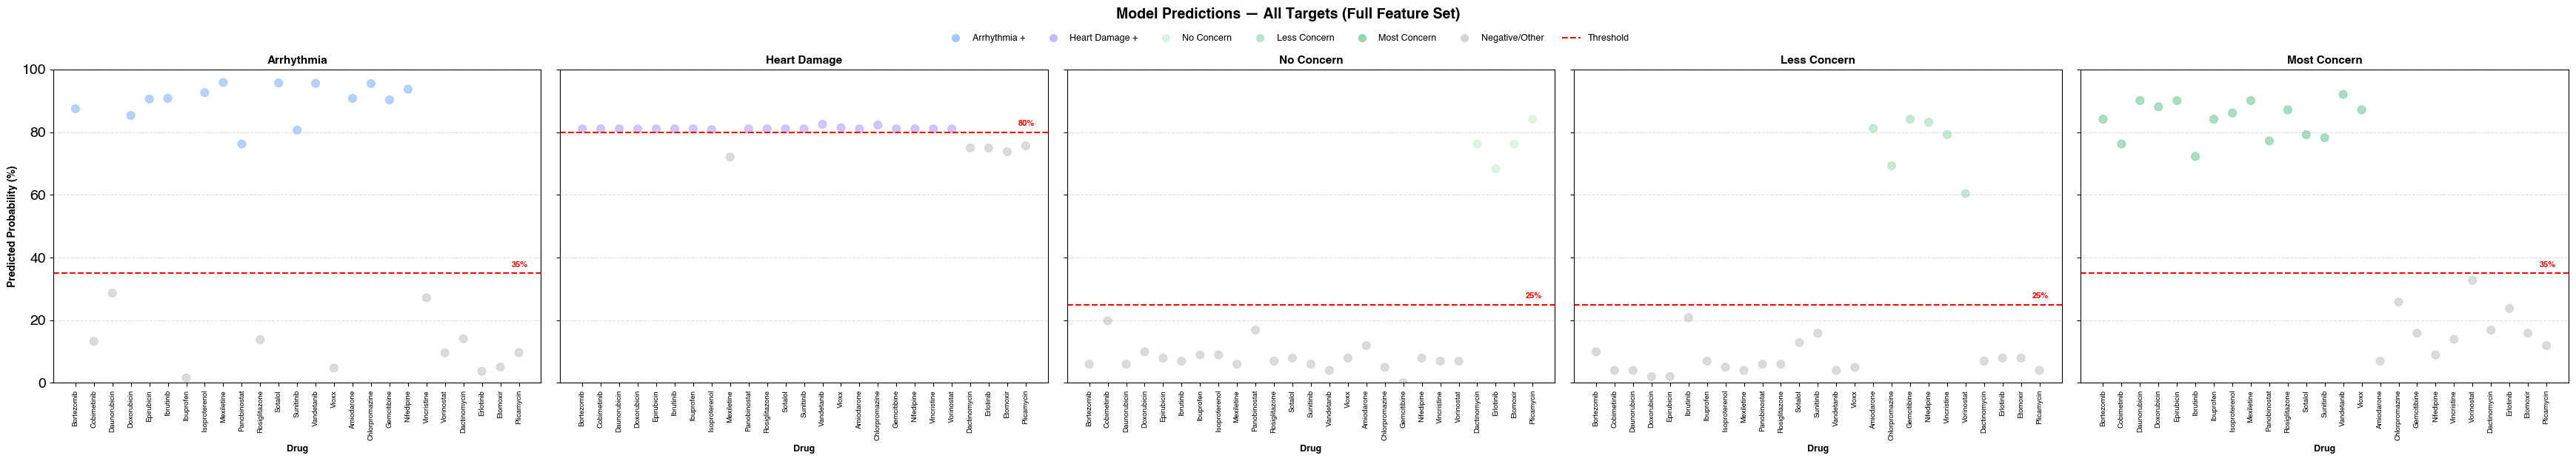


COMPUTED THRESHOLDS
  Arrhythmia: 35.0%
  Heart Damage: 80.0%
  No Concern: 25.0%
  Less Concern: 25.0%
  Most Concern: 35.0%

✓ All 5 prediction scatter plots generated in one row.


In [32]:
# Prediction Scatter Plots — All 5 Models in One Row (Arrhythmia First)
print("="*80)
print("PREDICTION SCATTER PLOTS — ALL MODELS (5 SUBPLOTS)")
print("="*80)

import numpy as np
import matplotlib.pyplot as plt

# Palette consistent with performance bars
arr_color = '#a3c9f9'      # Arrhythmia
hd_color = '#c8b7ff'       # Heart Damage
class_colors = ['#d8f3dc', '#b7e4c7', '#95d5b2']  # No / Less / Most Concern (light greens)
neg_color = 'lightgray'

# Get predictions for all drugs
full_preds_hd = model_heart_damage.predict_proba(features_df)[:, 1] * 100
full_preds_arr = model_arrhythmia.predict_proba(features_df)[:, 1] * 100
full_preds_concern = model_concern.predict_proba(features_df) * 100  # Shape: (n_drugs, 3)

drugs = df_raw['Drug']
positions = np.arange(len(drugs))

# Dynamic thresholds: set slightly above the highest negative prediction per target
margin_pp = 2.0  # wiggle room in percentage points

# ========================================
# Create 5 subplots in one horizontal row
# ========================================
fig, axes = plt.subplots(1, 5, figsize=(35, 6), sharey=True)

thresholds = {}
concern_thresholds = {}

# Get actual Concern labels for later
concern_actual = df_raw['Concern'].astype(str).str.strip().str.lower()
concern_map = {'no': 0, 'less': 1, 'most': 2}
concern_numeric = concern_actual.map(concern_map)

# ========================================
# Plot 1: Arrhythmia
# ========================================
ax = axes[0]
preds = full_preds_arr
label = 'Arrhythmia'

status = df_raw['Arrhythmia'].astype(bool)
point_colors = status.map({True: arr_color, False: neg_color})
ax.scatter(positions, preds, c=point_colors, alpha=0.8, s=60)
ax.set_xticks(positions)
ax.set_xticklabels(drugs, rotation=90, fontsize=7)
ax.set_title(f'{label}', fontsize=11, fontweight='bold')
ax.set_xlabel('Drug', fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_ylabel('Predicted Probability (%)', fontsize=10)
ax.set_ylim(0, 100)

# Compute threshold
neg_mask = ~status.values
if neg_mask.any():
    thr = float(np.max(preds[neg_mask])) + margin_pp
else:
    thr = float(np.percentile(preds, 50)) + margin_pp
thr = float(np.clip(thr, 0, 100))
thr = float(5 * np.ceil(thr / 5.0))
thresholds[label] = thr

# Add threshold line
ax.axhline(thr, color='red', linestyle='--', linewidth=1.5)
ax.text(len(drugs) - 0.5, thr + 1.5, f'{thr:.0f}%', color='red',
        fontsize=8, va='bottom', ha='right', fontweight='bold')

# ========================================
# Plot 2: Heart Damage
# ========================================
ax = axes[1]
preds = full_preds_hd
label = 'Heart Damage'

status = df_raw['heart_damage'].astype(bool)
point_colors = status.map({True: hd_color, False: neg_color})
ax.scatter(positions, preds, c=point_colors, alpha=0.8, s=60)
ax.set_xticks(positions)
ax.set_xticklabels(drugs, rotation=90, fontsize=7)
ax.set_title(f'{label}', fontsize=11, fontweight='bold')
ax.set_xlabel('Drug', fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_ylim(0, 100)

# Compute threshold
neg_mask = ~status.values
if neg_mask.any():
    thr = float(np.max(preds[neg_mask])) + margin_pp
else:
    thr = float(np.percentile(preds, 50)) + margin_pp
thr = float(np.clip(thr, 0, 100))
thr = float(5 * np.ceil(thr / 5.0))
thresholds[label] = thr

# Add threshold line
ax.axhline(thr, color='red', linestyle='--', linewidth=1.5)
ax.text(len(drugs) - 0.5, thr + 1.5, f'{thr:.0f}%', color='red',
        fontsize=8, va='bottom', ha='right', fontweight='bold')

# ========================================
# Plots 3-5: Concern (3 classes)
# ========================================
class_names = ['No Concern', 'Less Concern', 'Most Concern']

for idx, (class_name, class_color) in enumerate(zip(class_names, class_colors)):
    ax = axes[2 + idx]  # Plots 3, 4, 5
    preds = full_preds_concern[:, idx]

    # Color points: highlight if actual class matches, else gray
    point_colors = []
    for i, actual_class in enumerate(concern_numeric):
        if actual_class == idx:
            point_colors.append(class_color)
        else:
            point_colors.append(neg_color)

    ax.scatter(positions, preds, c=point_colors, alpha=0.8, s=60)
    ax.set_xticks(positions)
    ax.set_xticklabels(drugs, rotation=90, fontsize=7)
    ax.set_title(f'{class_name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Drug', fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_ylim(0, 100)

    # Compute threshold: highest prediction for non-class samples + margin
    neg_mask = (concern_numeric != idx).values
    if neg_mask.any():
        thr = float(np.max(preds[neg_mask])) + margin_pp
    else:
        thr = float(np.percentile(preds, 50)) + margin_pp
    thr = float(np.clip(thr, 0, 100))
    thr = float(5 * np.ceil(thr / 5.0))
    concern_thresholds[class_name] = thr

    # Add threshold line
    ax.axhline(thr, color='red', linestyle='--', linewidth=1.5)
    ax.text(len(drugs) - 0.5, thr + 1.5, f'{thr:.0f}%', color='red',
            fontsize=8, va='bottom', ha='right', fontweight='bold')

# ========================================
# Unified legend at top
# ========================================
legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=arr_color,
               label='Arrhythmia +', markersize=9),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=hd_color,
               label='Heart Damage +', markersize=9),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=class_colors[0],
               label='No Concern', markersize=9),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=class_colors[1],
               label='Less Concern', markersize=9),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=class_colors[2],
               label='Most Concern', markersize=9),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=neg_color,
               label='Negative/Other', markersize=9),
    plt.Line2D([0], [0], color='red', linestyle='--', linewidth=1.5, label='Threshold')
]

fig.legend(handles=legend_handles, loc='upper center', ncol=7,
           bbox_to_anchor=(0.5, 1.0), fontsize=9, frameon=False)

fig.suptitle('Model Predictions — All Targets (Full Feature Set)',
             fontsize=14, fontweight='bold', y=1.04)
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

# ========================================
# Print computed thresholds
# ========================================
print("\n" + "="*80)
print("COMPUTED THRESHOLDS")
print("="*80)
print(f"  Arrhythmia: {thresholds.get('Arrhythmia', 0):.1f}%")
print(f"  Heart Damage: {thresholds.get('Heart Damage', 0):.1f}%")
for class_name, thr in concern_thresholds.items():
    print(f"  {class_name}: {thr:.1f}%")

print("\n✓ All 5 prediction scatter plots generated in one row.")


## Step 12: Compare Model Performance

Compare the performance of all three models side-by-side.


ARRHYTHMIA, HEART DAMAGE, CONCERN METRICS (SKINNY, TIGHT BARS)


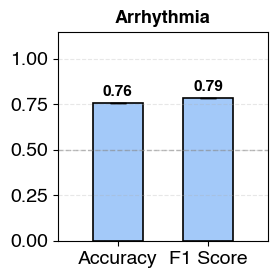

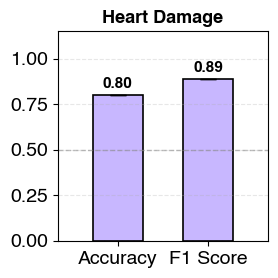

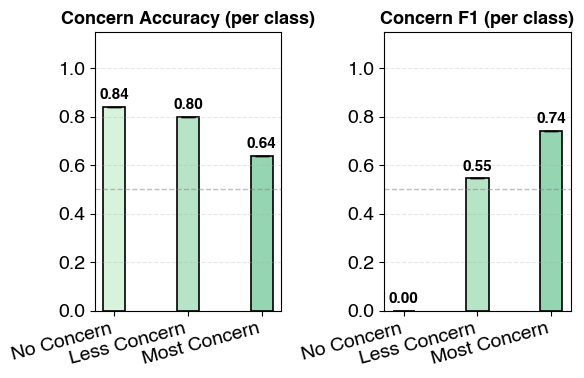

✓ Arrhythmia, Heart Damage, and Concern plots generated (skinny, tight bars).


In [10]:
print("="*80)
print("ARRHYTHMIA, HEART DAMAGE, CONCERN METRICS (SKINNY, TIGHT BARS)")
print("="*80)

import numpy as np
import matplotlib.pyplot as plt

arr_color = '#a3c9f9'     # Arrhythmia blue
hd_color  = '#c8b7ff'     # Heart Damage purple
concern_colors = ['#d8f3dc', '#b7e4c7', '#95d5b2']
concern_classes = ['No Concern', 'Less Concern', 'Most Concern']

def _add_labels(ax, bars, vals, stds):
    for bar, val, std in zip(bars, vals, stds):
        y_pos = bar.get_height() + std + 0.02 if std > 0 else bar.get_height() + 0.02
        ax.text(bar.get_x() + bar.get_width()/2, y_pos, f'{val:.2f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Arrhythmia: skinny, tight bars
fig, ax = plt.subplots(figsize=(3, 3))
bar_width = 0.1
x = np.array([0, 0.18])  # closer spacing
arr_means = [results_arrhythmia['accuracy'], results_arrhythmia['f1']]
arr_stds  = [0,  0]
bars = ax.bar(x, arr_means, bar_width, yerr=arr_stds,
              color=[arr_color, arr_color], edgecolor='black', linewidth=1.2,
              capsize=6, error_kw={'linewidth': 1.5})
_add_labels(ax, bars, arr_means, arr_stds)
ax.set_xticks(x)
ax.set_xticklabels(['Accuracy', 'F1 Score'])
ax.set_xlim(-0.12, 0.3)  # trim side padding
ax.set_title('Arrhythmia', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Heart Damage: skinny, tight bars (purple)
fig, ax = plt.subplots(figsize=(3, 3))
hd_means = [results_heart_damage['accuracy'], results_heart_damage['f1']]
hd_stds  = [0,  0]
bars = ax.bar(x, hd_means, bar_width, yerr=hd_stds,
              color=[hd_color, hd_color], edgecolor='black', linewidth=1.2,
              capsize=6, error_kw={'linewidth': 1.5})
_add_labels(ax, bars, hd_means, hd_stds)
ax.set_xticks(x)
ax.set_xticklabels(['Accuracy', 'F1 Score'])
ax.set_xlim(-0.12, 0.3)
ax.set_title('Heart Damage', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Concern model: per-class Accuracy + F1 (unchanged)
concern_acc_means = [results_concern['per_class_accuracy'].get(i, 0) for i in range(3)]
concern_acc_stds  = [0 for i in range(3)]  # No std in LOOCV
concern_f1_means  = [results_concern['per_class_f1'].get(i, 0) for i in range(3)]
concern_f1_stds   = [0 for i in range(3)]  # No std in LOOCV
x_c = np.arange(len(concern_classes))
bar_width_c = 0.3

fig, axes = plt.subplots(1, 2, figsize=(6, 4))

acc_bars = axes[0].bar(x_c, concern_acc_means, bar_width_c, yerr=concern_acc_stds,
                       color=concern_colors, edgecolor='black', linewidth=1.2,
                       capsize=5, error_kw={'linewidth': 1.5})
_add_labels(axes[0], acc_bars, concern_acc_means, concern_acc_stds)
axes[0].set_title('Concern Accuracy (per class)', fontsize=13, fontweight='bold')
axes[0].set_xticks(x_c)
axes[0].set_xticklabels(concern_classes, rotation=15, ha='right')
axes[0].set_ylim(0, 1.15)
axes[0].axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)
axes[0].grid(axis='y', linestyle='--', alpha=0.3)

f1_bars = axes[1].bar(x_c, concern_f1_means, bar_width_c, yerr=concern_f1_stds,
                      color=concern_colors, edgecolor='black', linewidth=1.2,
                      capsize=5, error_kw={'linewidth': 1.5})
_add_labels(axes[1], f1_bars, concern_f1_means, concern_f1_stds)
axes[1].set_title('Concern F1 (per class)', fontsize=13, fontweight='bold')
axes[1].set_xticks(x_c)
axes[1].set_xticklabels(concern_classes, rotation=15, ha='right')
axes[1].set_ylim(0, 1.15)
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)
axes[1].grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Arrhythmia, Heart Damage, and Concern plots generated (skinny, tight bars).")


PLOTTING ROC CURVES (LOOCV - AGGREGATED)


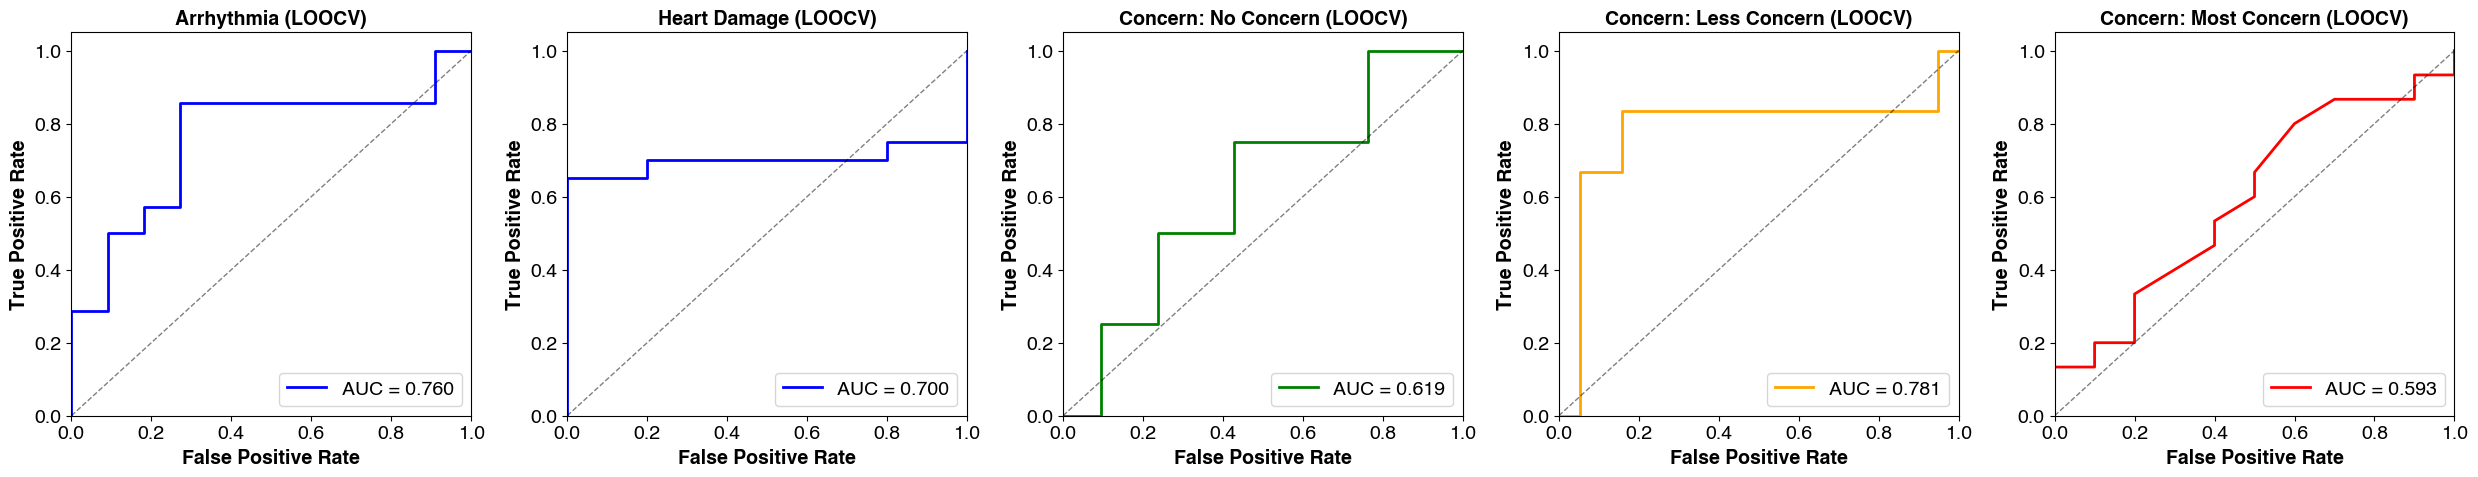


ROC curves saved to Output/ROC_Data/ROC_All_LOOCV.png


In [11]:
# Cell #22: ROC CURVE PLOTS - All 5 in One Row (LOOCV)
# Depends on: 13 (Arrhythmia), 15 (Heart Damage), 17 (Concern)

import matplotlib.pyplot as plt

print("="*80)
print("PLOTTING ROC CURVES (LOOCV - AGGREGATED)")
print("="*80)

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

# 1. Arrhythmia ROC
ax = axes[0]
ax.plot(results_arrhythmia['fpr'], results_arrhythmia['tpr'],
        color='b', lw=2, label=f'AUC = {results_arrhythmia["auc"]:.3f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Arrhythmia (LOOCV)')
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])

# 2. Heart Damage ROC
ax = axes[1]
ax.plot(results_heart_damage['fpr'], results_heart_damage['tpr'],
        color='b', lw=2, label=f'AUC = {results_heart_damage["auc"]:.3f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Heart Damage (LOOCV)')
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])

# 3-5. Concern per-class ROC
colors = ['green', 'orange', 'red']
class_names = ['No Concern', 'Less Concern', 'Most Concern']

for i, (cls_idx, color, cls_name) in enumerate(zip([0, 1, 2], colors, class_names)):
    ax = axes[2 + i]
    if cls_idx in results_concern['per_class']:
        cls_data = results_concern['per_class'][cls_idx]
        ax.plot(cls_data['fpr'], cls_data['tpr'],
                color=color, lw=2, label=f'AUC = {cls_data["auc"]:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'Concern: {cls_name} (LOOCV)')
    ax.legend(loc='lower right')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'Output' / 'ROC_Data' / 'ROC_All_LOOCV.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

print("\nROC curves saved to Output/ROC_Data/ROC_All_LOOCV.png")


CONFUSION MATRICES FOR ALL MODELS (Aggregated from All 3 Folds)
Arrhythmia threshold: 35.0% | Total samples: 25
Heart Damage threshold: 80.0% | Total samples: 25


c:\Users\NoahB\miniconda3\envs\jupyter-ai-claude\Lib\site-packages\xgboost\training.py:199: UserWarning: [11:22:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\NoahB\miniconda3\envs\jupyter-ai-claude\Lib\site-packages\xgboost\training.py:199: UserWarning: [11:22:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\NoahB\miniconda3\envs\jupyter-ai-claude\Lib\site-packages\xgboost\training.py:199: UserWarning: [11:22:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Concern: argmax prediction | Total samples: 25


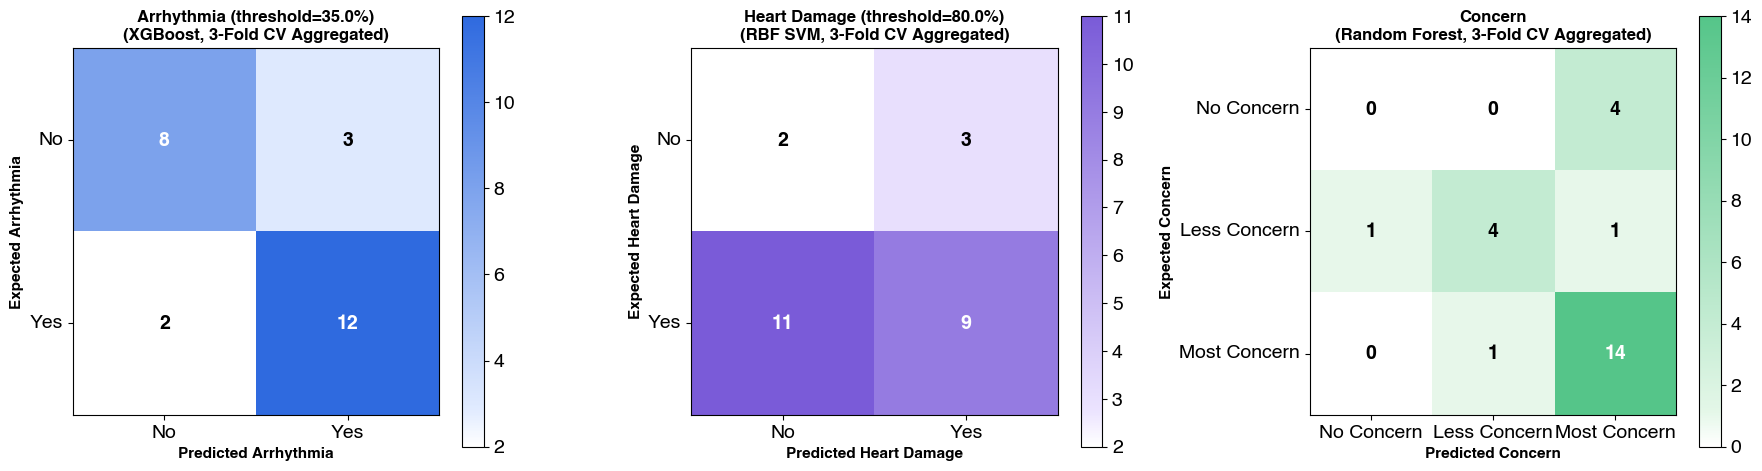


CLASSIFICATION REPORTS (Aggregated from All 3 Folds)

--- Arrhythmia ---
Total samples: 25
               precision    recall  f1-score   support

No Arrhythmia       0.80      0.73      0.76        11
   Arrhythmia       0.80      0.86      0.83        14

     accuracy                           0.80        25
    macro avg       0.80      0.79      0.79        25
 weighted avg       0.80      0.80      0.80        25


--- Heart Damage ---
Total samples: 25
              precision    recall  f1-score   support

   No Damage       0.15      0.40      0.22         5
      Damage       0.75      0.45      0.56        20

    accuracy                           0.44        25
   macro avg       0.45      0.43      0.39        25
weighted avg       0.63      0.44      0.49        25


--- Concern ---
Total samples: 25
              precision    recall  f1-score   support

  No Concern       0.00      0.00      0.00         4
Less Concern       0.80      0.67      0.73         6
Most Conce

c:\Users\NoahB\miniconda3\envs\jupyter-ai-claude\Lib\site-packages\xgboost\training.py:199: UserWarning: [11:22:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✓ Models restored to full-data state.


In [13]:
# Confusion Matrices — Arrhythmia, Heart Damage, and Concern (Aggregated across 3 folds)
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

print("="*80)
print("CONFUSION MATRICES FOR ALL MODELS (Aggregated from All 3 Folds)")
print("="*80)

# Thresholds pulled from earlier computation
arr_threshold = thresholds.get('Arrhythmia', 35.0) / 100.0
hd_threshold = thresholds.get('Heart Damage', 70.0) / 100.0

# ----------------------------------------
# Arrhythmia: aggregate predictions
# ----------------------------------------
cv_arr = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
arr_y_true_all, arr_y_pred_all = [], []

for fold_idx, (train_idx, test_idx) in enumerate(cv_arr.split(features_df, arrhythmia), start=1):
    X_train, X_test = features_df.iloc[train_idx], features_df.iloc[test_idx]
    y_train = arrhythmia[train_idx] if isinstance(arrhythmia, np.ndarray) else arrhythmia.iloc[train_idx]
    y_test = arrhythmia[test_idx] if isinstance(arrhythmia, np.ndarray) else arrhythmia.iloc[test_idx]

    model_arrhythmia.fit(X_train, y_train)
    y_proba = model_arrhythmia.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= arr_threshold).astype(int)

    arr_y_true_all.extend(y_test)
    arr_y_pred_all.extend(y_pred)

arr_y_true_all = np.array(arr_y_true_all)
arr_y_pred_all = np.array(arr_y_pred_all)
print(f"Arrhythmia threshold: {arr_threshold*100:.1f}% | Total samples: {len(arr_y_true_all)}")

# ----------------------------------------
# Heart Damage: aggregate predictions
# ----------------------------------------
cv_hd = StratifiedKFold(n_splits=3, shuffle=True, random_state=21)
hd_y_true_all, hd_y_pred_all = [], []

for fold_idx, (train_idx, test_idx) in enumerate(cv_hd.split(features_df, heart_damage), start=1):
    X_train, X_test = features_df.iloc[train_idx], features_df.iloc[test_idx]
    y_train = heart_damage[train_idx] if isinstance(heart_damage, np.ndarray) else heart_damage.iloc[train_idx]
    y_test = heart_damage[test_idx] if isinstance(heart_damage, np.ndarray) else heart_damage.iloc[test_idx]

    model_heart_damage.fit(X_train, y_train)
    y_proba = model_heart_damage.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= hd_threshold).astype(int)

    hd_y_true_all.extend(y_test)
    hd_y_pred_all.extend(y_pred)

hd_y_true_all = np.array(hd_y_true_all)
hd_y_pred_all = np.array(hd_y_pred_all)
print(f"Heart Damage threshold: {hd_threshold*100:.1f}% | Total samples: {len(hd_y_true_all)}")

# ----------------------------------------
# Concern: aggregate predictions
# ----------------------------------------
cv_concern = StratifiedKFold(n_splits=3, shuffle=True, random_state=122)
concern_y_true_all, concern_y_pred_all = [], []

for fold_idx, (train_idx, test_idx) in enumerate(cv_concern.split(features_df, concern), start=1):
    X_train, X_test = features_df.iloc[train_idx], features_df.iloc[test_idx]
    y_train = concern[train_idx] if isinstance(concern, np.ndarray) else concern.iloc[train_idx]
    y_test = concern[test_idx] if isinstance(concern, np.ndarray) else concern.iloc[test_idx]

    model_concern.fit(X_train, y_train)
    y_pred = model_concern.predict(X_test)

    concern_y_true_all.extend(y_test)
    concern_y_pred_all.extend(y_pred)

concern_y_true_all = np.array(concern_y_true_all)
concern_y_pred_all = np.array(concern_y_pred_all)
print(f"Concern: argmax prediction | Total samples: {len(concern_y_true_all)}")

# Custom palettes: white only at 0, then light mids, darker highs
light_blue_cmap = mcolors.LinearSegmentedColormap.from_list(
    'light_blue', [(0.0, '#ffffff'), (0.08, '#e2ecff'), (1.0, '#2f6adf')])
light_purple_cmap = mcolors.LinearSegmentedColormap.from_list(
    'light_purple', [(0.0, '#ffffff'), (0.08, '#ece4ff'), (1.0, '#7a5bd8')])
light_green_cmap = mcolors.LinearSegmentedColormap.from_list(
    'light_green_3', [(0.0, '#ffffff'), (0.08, '#e4f7e8'), (1.0, '#55c589')])

# ----------------------------------------
# Plot aggregated confusion matrices
# ----------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Arrhythmia
cm_arr = confusion_matrix(arr_y_true_all, arr_y_pred_all)
ax1 = axes[0]
im1 = ax1.imshow(cm_arr, interpolation='nearest', cmap=light_blue_cmap)
ax1.figure.colorbar(im1, ax=ax1)
ax1.set(xticks=[0, 1], yticks=[0, 1],
        xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
ax1.set_yticklabels(['No', 'Yes'], rotation=0, va='center')
ax1.set_xlabel('Predicted Arrhythmia', fontsize=11, fontweight='bold')
ax1.set_ylabel('Expected Arrhythmia', fontsize=11, fontweight='bold')
ax1.set_title(f'Arrhythmia (threshold={arr_threshold*100:.1f}%)\n(XGBoost, 3-Fold CV Aggregated)', fontsize=12, fontweight='bold')

thresh1 = cm_arr.max() / 2.
for i in range(cm_arr.shape[0]):
    for j in range(cm_arr.shape[1]):
        ax1.text(j, i, format(cm_arr[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm_arr[i, j] > thresh1 else "black",
                 fontsize=14, fontweight='bold')

# 2) Heart Damage
cm_hd = confusion_matrix(hd_y_true_all, hd_y_pred_all)
ax2 = axes[1]
im2 = ax2.imshow(cm_hd, interpolation='nearest', cmap=light_purple_cmap)
ax2.figure.colorbar(im2, ax=ax2)
ax2.set(xticks=[0, 1], yticks=[0, 1],
        xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
ax2.set_yticklabels(['No', 'Yes'], rotation=0, va='center')
ax2.set_xlabel('Predicted Heart Damage', fontsize=11, fontweight='bold')
ax2.set_ylabel('Expected Heart Damage', fontsize=11, fontweight='bold')
ax2.set_title(f'Heart Damage (threshold={hd_threshold*100:.1f}%)\n(RBF SVM, 3-Fold CV Aggregated)', fontsize=12, fontweight='bold')

thresh2 = cm_hd.max() / 2.
for i in range(cm_hd.shape[0]):
    for j in range(cm_hd.shape[1]):
        ax2.text(j, i, format(cm_hd[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm_hd[i, j] > thresh2 else "black",
                 fontsize=14, fontweight='bold')

# 3) Concern (multiclass)
cm_concern = confusion_matrix(concern_y_true_all, concern_y_pred_all)
ax3 = axes[2]
im3 = ax3.imshow(cm_concern, interpolation='nearest', cmap=light_green_cmap)
ax3.figure.colorbar(im3, ax=ax3)
ax3.set(xticks=[0, 1, 2], yticks=[0, 1, 2],
        xticklabels=['No Concern', 'Less Concern', 'Most Concern'],
        yticklabels=['No Concern', 'Less Concern', 'Most Concern'])
ax3.set_yticklabels(['No Concern', 'Less Concern', 'Most Concern'], rotation=0, va='center')
ax3.set_xlabel('Predicted Concern', fontsize=11, fontweight='bold')
ax3.set_ylabel('Expected Concern', fontsize=11, fontweight='bold')
ax3.set_title('Concern\n(Random Forest, 3-Fold CV Aggregated)', fontsize=12, fontweight='bold')

thresh3 = cm_concern.max() / 2.
for i in range(cm_concern.shape[0]):
    for j in range(cm_concern.shape[1]):
        ax3.text(j, i, format(cm_concern[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm_concern[i, j] > thresh3 else "black",
                 fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# ----------------------------------------
# Classification reports (aggregated)
# ----------------------------------------
print("\n" + "="*80)
print("CLASSIFICATION REPORTS (Aggregated from All 3 Folds)")
print("="*80)

print("\n--- Arrhythmia ---")
print(f"Total samples: {len(arr_y_true_all)}")
print(classification_report(arr_y_true_all, arr_y_pred_all,
                            target_names=['No Arrhythmia', 'Arrhythmia'], zero_division=0))

print("\n--- Heart Damage ---")
print(f"Total samples: {len(hd_y_true_all)}")
print(classification_report(hd_y_true_all, hd_y_pred_all,
                            target_names=['No Damage', 'Damage'], zero_division=0))

print("\n--- Concern ---")
print(f"Total samples: {len(concern_y_true_all)}")
print(classification_report(concern_y_true_all, concern_y_pred_all,
                            target_names=['No Concern', 'Less Concern', 'Most Concern'], zero_division=0))

print("\n✓ Confusion matrices for all models generated (aggregated from all 3 folds).")

# Retrain final models on all data (restore state)
print("\nRetraining final models on all data...")
model_arrhythmia.fit(features_df, arrhythmia)
model_heart_damage.fit(features_df, heart_damage)
model_concern.fit(features_df, concern)
print("✓ Models restored to full-data state.")


Need to define the threshold for the confusion matricies before running them.

## Step 13: Feature Importance Summary

Compare which PK-PD elimination coefficients are most important for each target.


FEATURE IMPORTANCE/COEFFICIENT SUMMARY
Note: Different models provide different interpretability:
  - XGBoost (Arrhythmia): Feature importances
  - Gaussian Kernel (Heart Damage): Permutation importance
  - Random Forest (Concern): Feature importances

Top 10 Features for Arrhythmia (XGBoost Feature Importances):


,Feature,Importance
0,R0_Contractility,0.354537
6,k_elim_Contractility,0.101829
13,k_elim_O2,0.086110
7,R0_O2,0.085311
9,kappa_O2,0.076210
10,n_O2,0.063323
8,Emax_O2,0.059279
2,kappa_Contractility,0.058990
11,m_O2,0.037418
1,Emax_Contractility,0.033310



Computing permutation importance for Heart Damage (Gaussian Kernel)...

Top 10 Features for Heart Damage (Permutation Importance):


,Feature,Importance
0,R0_Contractility,0.0
1,Emax_Contractility,0.0
2,kappa_Contractility,0.0
3,n_Contractility,0.0
4,m_Contractility,0.0
5,tau_Contractility,0.0
6,k_elim_Contractility,0.0
7,R0_O2,0.0
8,Emax_O2,0.0
9,kappa_O2,0.0



Top 10 Features for Concern (Random Forest Feature Importances):


,Feature,Importance
10,n_O2,0.151250
0,R0_Contractility,0.102386
1,Emax_Contractility,0.099444
6,k_elim_Contractility,0.085021
11,m_O2,0.080335
5,tau_Contractility,0.065944
13,k_elim_O2,0.065799
7,R0_O2,0.065522
12,tau_O2,0.064490
9,kappa_O2,0.064430



GENERATING CUMULATIVE FEATURE PLOTS (5 SUBPLOTS)


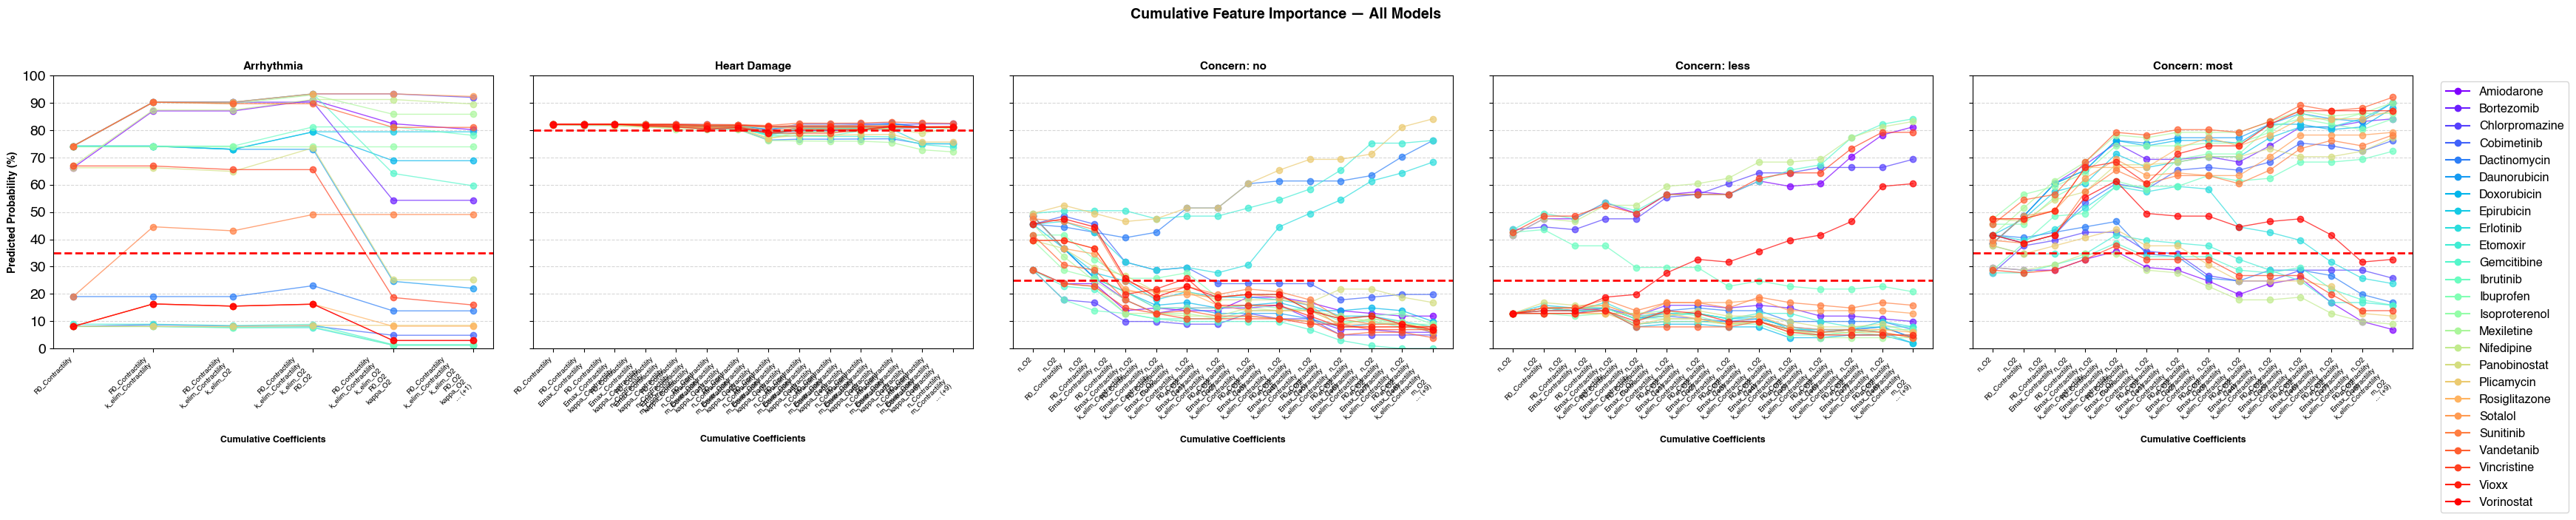


TOP FEATURES COMPARISON

Top 5 features by model:
Arrhythmia: k_elim_Contractility, k_elim_O2, R0_O2, kappa_O2, R0_Contractility
Heart Damage: n_Contractility, Emax_Contractility, kappa_Contractility, m_Contractility, R0_Contractility
Concern: k_elim_Contractility, Emax_Contractility, R0_Contractility, m_O2, n_O2

Features in top 5 for ALL models: 1
  ['R0_Contractility']

Features in top 5 for Arrhythmia + Heart Damage only: 0

Features in top 5 for Arrhythmia + Concern only: 1
  ['k_elim_Contractility']

Features in top 5 for Heart Damage + Concern only: 1
  ['Emax_Contractility']

✓ Feature importance summary with thresholds complete!


In [14]:
# Cell 14: Feature Importance Summary with Threshold Lines
print("="*80)
print("FEATURE IMPORTANCE/COEFFICIENT SUMMARY")
print("="*80)
print("Note: Different models provide different interpretability:")
print("  - XGBoost (Arrhythmia): Feature importances")
print("  - Gaussian Kernel (Heart Damage): Permutation importance")
print("  - Random Forest (Concern): Feature importances")
print("="*80)

from matplotlib.lines import Line2D

top_n = 10

print(f"\nTop {top_n} Features for Arrhythmia (XGBoost Feature Importances):")
# Resolve arrhythmia feature importances (robust to missing key)
arr_importances = None
if 'results_arrhythmia' in globals() and isinstance(results_arrhythmia, dict):
    arr_importances = results_arrhythmia.get('feature_importances')
if arr_importances is None and 'importance_df_arrhythmia' in globals():
    arr_importances = importance_df_arrhythmia
if arr_importances is None and 'model_arrhythmia' in globals():
    arr_importances = pd.DataFrame({
        'Feature': features_df.columns,
        'Importance': model_arrhythmia.named_steps['xgb'].feature_importances_
    }).sort_values('Importance', ascending=False)
if arr_importances is not None:
    results_arrhythmia['feature_importances'] = arr_importances
display(arr_importances.head(top_n))

# Compute permutation importance for Heart Damage if not already done
if 'heart_damage_importances' not in globals():
    from sklearn.inspection import permutation_importance
    print("\nComputing permutation importance for Heart Damage (Gaussian Kernel)...")
    perm_importance = permutation_importance(
        model_heart_damage,
        features_df,
        heart_damage,
        n_repeats=10,
        random_state=42,
        n_jobs=-1
    )
    heart_damage_importances = pd.DataFrame({
        'Feature': features_df.columns,
        'Importance': perm_importance.importances_mean
    }).sort_values('Importance', ascending=False)

print(f"\nTop {top_n} Features for Heart Damage (Permutation Importance):")
display(heart_damage_importances.head(top_n))

print(f"\nTop {top_n} Features for Concern (Random Forest Feature Importances):")
display(results_concern['feature_importances'].head(top_n))

# ========================================
# CUMULATIVE FEATURE IMPORTANCE PLOTS WITH THRESHOLDS
# ONE LONG HORIZONTAL FIGURE (5 SUBPLOTS)
# ========================================
import matplotlib.pyplot as plt

# Get thresholds from earlier computation
arr_threshold = thresholds.get('Arrhythmia', 35.0)
hd_threshold = thresholds.get('Heart Damage', 70.0)

print("\n" + "="*80)
print("GENERATING CUMULATIVE FEATURE PLOTS (5 SUBPLOTS)")
print("="*80)

# Prepare color map and legend order (alphabetical drugs)
drug_list = sorted(df_raw['Drug'].unique())
cmap = plt.get_cmap('rainbow')
color_map = {
    drug: cmap(0.0 if len(drug_list) == 1 else i / (len(drug_list) - 1))
    for i, drug in enumerate(drug_list)
}

# ========================================
# Prepare data for all 5 plots
# ========================================

# 1. Arrhythmia
top_features_arr = results_arrhythmia['feature_importances'].head(6)['Feature'].tolist()
drug_preds_arr = []
for drug in df_raw['Drug']:
    drug_idx = df_raw.index[df_raw['Drug'] == drug][0]
    for rank in range(1, len(top_features_arr) + 1):
        single_vector = pd.DataFrame(0, index=[0], columns=features_df.columns)
        for past_feature in top_features_arr[:rank]:
            single_vector[past_feature] = features_df.loc[drug_idx, past_feature]
        prob = model_arrhythmia.predict_proba(single_vector)[:, 1][0]
        drug_preds_arr.append({
            'Drug': drug,
            'Rank': rank,
            'Arrhythmia (%)': prob * 100
        })
plot_df_arr = pd.DataFrame(drug_preds_arr)

# 2. Heart Damage
top_features_hd = heart_damage_importances['Feature'].tolist()
num_features_hd = len(top_features_hd)
drug_preds_hd = []
for drug in df_raw['Drug']:
    drug_idx = df_raw.index[df_raw['Drug'] == drug][0]
    for rank in range(1, num_features_hd + 1):
        single_vector = pd.DataFrame(0, index=[0], columns=features_df.columns)
        for past_feature in top_features_hd[:rank]:
            single_vector[past_feature] = features_df.loc[drug_idx, past_feature]
        prob = model_heart_damage.predict_proba(single_vector)[:, 1][0]
        drug_preds_hd.append({
            'Drug': drug,
            'Rank': rank,
            'Heart Damage (%)': prob * 100
        })
plot_df_hd = pd.DataFrame(drug_preds_hd)

# 3. Concern (all 3 classes)
top_features_concern = results_concern['feature_importances']['Feature'].tolist()
num_features_concern = len(top_features_concern)
drug_preds_concern = []
for drug in df_raw['Drug']:
    drug_idx = df_raw.index[df_raw['Drug'] == drug][0]
    for rank in range(1, num_features_concern + 1):
        single_vector = pd.DataFrame(0, index=[0], columns=features_df.columns)
        for feature in top_features_concern[:rank]:
            single_vector[feature] = features_df.loc[drug_idx, feature]
        probs = model_concern.predict_proba(single_vector)[0]
        drug_preds_concern.append({
            'Drug': drug,
            'Rank': rank,
            'Concern: no (%)': probs[0] * 100,
            'Concern: less (%)': probs[1] * 100,
            'Concern: most (%)': probs[2] * 100
        })
plot_df_concern = pd.DataFrame(drug_preds_concern)

# ========================================
# Create 5 subplots in one horizontal figure
# ========================================
fig, axes = plt.subplots(1, 5, figsize=(35, 6), sharey=True)

# Get concern thresholds
concern_thr_no = concern_thresholds.get('No Concern', 50.0)
concern_thr_less = concern_thresholds.get('Less Concern', 50.0)
concern_thr_most = concern_thresholds.get('Most Concern', 50.0)

# ========================================
# Plot 1: Arrhythmia
# ========================================
ax = axes[0]

def stacked_label_arr(rank):
    if rank <= 5:
        return "\n".join(top_features_arr[:rank])
    else:
        return "\n".join(top_features_arr[:5]) + f"\n... (+{rank-5})"

xtick_labels_arr = [stacked_label_arr(i) for i in range(1, len(top_features_arr) + 1)]

for drug in drug_list:
    subset = plot_df_arr[plot_df_arr['Drug'] == drug]
    ax.plot(subset['Rank'], subset['Arrhythmia (%)'], marker='o', label=drug,
            alpha=0.7, linewidth=1, color=color_map[drug])

ax.axhline(y=arr_threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold = {arr_threshold:.1f}%')
ax.set_xticks(range(1, len(top_features_arr) + 1))
ax.set_xticklabels(xtick_labels_arr, rotation=45, ha='right', fontsize=7)
ax.set_yticks(np.linspace(0, 100, 11))
ax.set_ylim(0, 100)
ax.set_xlabel('Cumulative Coefficients', fontsize=9)
ax.set_ylabel('Predicted Probability (%)', fontsize=10)
ax.set_title('Arrhythmia', fontsize=11, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.5)

# ========================================
# Plot 2: Heart Damage
# ========================================
ax = axes[1]

def stacked_label_hd(rank):
    if rank <= 5:
        return "\n".join(top_features_hd[:rank])
    else:
        return "\n".join(top_features_hd[:5]) + f"\n... (+{rank-5})"

xtick_labels_hd = [stacked_label_hd(i) for i in range(1, num_features_hd + 1)]

for drug in drug_list:
    subset = plot_df_hd[plot_df_hd['Drug'] == drug]
    ax.plot(subset['Rank'], subset['Heart Damage (%)'], marker='o', label=drug,
            alpha=0.7, linewidth=1, color=color_map[drug])

ax.axhline(y=hd_threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold = {hd_threshold:.1f}%')
ax.set_xticks(range(1, num_features_hd + 1))
ax.set_xticklabels(xtick_labels_hd, rotation=45, ha='right', fontsize=7)
ax.set_yticks(np.linspace(0, 100, 11))
ax.set_ylim(0, 100)
ax.set_xlabel('Cumulative Coefficients', fontsize=9)
ax.set_title('Heart Damage', fontsize=11, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.5)

# ========================================
# Plots 3-5: Concern (3 classes)
# ========================================
def stacked_label_concern(rank):
    if rank <= 5:
        return "\n".join(top_features_concern[:rank])
    else:
        return "\n".join(top_features_concern[:5]) + f"\n... (+{rank-5})"

xtick_labels_concern = [stacked_label_concern(i) for i in range(1, num_features_concern + 1)]

class_labels = ['Concern: no', 'Concern: less', 'Concern: most']
concern_thrs = [concern_thr_no, concern_thr_less, concern_thr_most]

for idx, (class_label, thr) in enumerate(zip(class_labels, concern_thrs)):
    ax = axes[2 + idx]  # Plots 3, 4, 5
    column_name = f'{class_label} (%)'
    for drug in drug_list:
        subset = plot_df_concern[plot_df_concern['Drug'] == drug]
        ax.plot(subset['Rank'], subset[column_name], marker='o', label=drug,
                alpha=0.7, linewidth=1, color=color_map[drug])
    ax.axhline(y=thr, color='red', linestyle='--', linewidth=2, label=f'Threshold = {thr:.1f}%')
    ax.set_xticks(range(1, num_features_concern + 1))
    ax.set_xticklabels(xtick_labels_concern, rotation=45, ha='right', fontsize=7)
    ax.set_yticks(np.linspace(0, 100, 11))
    ax.set_ylim(0, 100)
    ax.set_xlabel('Cumulative Coefficients', fontsize=9)
    ax.set_title(class_label, fontsize=11, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# ========================================
# Legend on rightmost subplot (alphabetical drugs, rainbow colors)
# ========================================
legend_handles = [
    Line2D([0], [0], color=color_map[drug], marker='o', linestyle='-', label=drug)
    for drug in drug_list
]
axes[4].legend(handles=legend_handles, bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1, fontsize='small')

fig.suptitle('Cumulative Feature Importance — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ========================================
# Top Features Comparison
# ========================================
print("\n" + "="*80)
print("TOP FEATURES COMPARISON")
print("="*80)

top_arr = set(results_arrhythmia['feature_importances'].head(5)['Feature'].values)
top_hd = set(heart_damage_importances.head(5)['Feature'].values)
top_con = set(results_concern['feature_importances'].head(5)['Feature'].values)

print("\nTop 5 features by model:")
print(f"Arrhythmia: {', '.join(top_arr)}")
print(f"Heart Damage: {', '.join(top_hd)}")
print(f"Concern: {', '.join(top_con)}")

common_all = top_arr & top_hd & top_con
common_arr_hd = (top_arr & top_hd) - common_all
common_arr_con = (top_arr & top_con) - common_all
common_hd_con = (top_hd & top_con) - common_all

print(f"\nFeatures in top 5 for ALL models: {len(common_all)}")
if common_all:
    print(f"  {list(common_all)}")

print(f"\nFeatures in top 5 for Arrhythmia + Heart Damage only: {len(common_arr_hd)}")
if common_arr_hd:
    print(f"  {list(common_arr_hd)}")

print(f"\nFeatures in top 5 for Arrhythmia + Concern only: {len(common_arr_con)}")
if common_arr_con:
    print(f"  {list(common_arr_con)}")

print(f"\nFeatures in top 5 for Heart Damage + Concern only: {len(common_hd_con)}")
if common_hd_con:
    print(f"  {list(common_hd_con)}")

print("\n✓ Feature importance summary with thresholds complete!")


## SHAP Feature Importance - Arrhythmia + Heart Damage Model
SHAP (SHapley Additive exPlanations) provides a unified measure of feature importance by assigning each feature an importance value for a particular prediction.

In [29]:
# Compute SHAP Values for All Models
import numpy as np
import pandas as pd
import shap

print("="*80)
print("COMPUTING SHAP VALUES — ALL MODELS")
print("="*80)

# ===========================
# 1. Arrhythmia: XGBoost
# ===========================
print("\n1. Computing SHAP for Arrhythmia (XGBoost)...")
xgb_model = model_arrhythmia.named_steps['xgb']
scaler_arr = model_arrhythmia.named_steps['scaler']
X_scaled_arr = scaler_arr.transform(features_df)
X_scaled_arr_df = pd.DataFrame(X_scaled_arr, columns=features_df.columns, index=features_df.index)

explainer_arr = shap.TreeExplainer(xgb_model)
shap_values_arr = explainer_arr.shap_values(X_scaled_arr)        

# ===========================
# 2. Heart Damage: RBF SVM (KernelSHAP)
# ===========================
print("2. Computing SHAP for Heart Damage (RBF SVM, KernelSHAP)...")
feature_names_hd = features_df.columns.tolist()

def predict_hd(X):
    X_df = pd.DataFrame(X, columns=feature_names_hd)
    return model_heart_damage.predict_proba(X_df)[:, 1]

try:
    background_hd = shap.kmeans(features_df, k=min(10, len(features_df)))
except Exception:
    background_hd = features_df.sample(min(10, len(features_df)), random_state=42).values

explainer_hd = shap.KernelExplainer(predict_hd, background_hd)   
shap_values_hd = explainer_hd.shap_values(features_df.values, nsamples='auto')

# ===========================
# 3. Concern: Random Forest (3 Classes)
# ===========================
print("3. Computing SHAP for Concern (Random Forest, 3 classes)...")
rf_model = model_concern.named_steps['rf']
scaler_concern = model_concern.named_steps['scaler']
X_scaled_concern = scaler_concern.transform(features_df)
X_scaled_concern_df = pd.DataFrame(X_scaled_concern, columns=features_df.columns, index=features_df.index)

explainer_concern = shap.TreeExplainer(rf_model)
shap_values_concern_raw = explainer_concern.shap_values(X_scaled_concern)

if isinstance(shap_values_concern_raw, list):
    shap_values_concern = shap_values_concern_raw
else:
    n_classes = shap_values_concern_raw.shape[2] if len(shap_values_concern_raw.shape) == 3 else 3
    shap_values_concern = [shap_values_concern_raw[:, :, i] for i in range(n_classes)]

print("\n✓ SHAP values computed for all models.")

COMPUTING SHAP VALUES — ALL MODELS

1. Computing SHAP for Arrhythmia (XGBoost)...
2. Computing SHAP for Heart Damage (RBF SVM, KernelSHAP)...


  0%|          | 0/25 [00:00<?, ?it/s]

3. Computing SHAP for Concern (Random Forest, 3 classes)...

✓ SHAP values computed for all models.


PLOTTING SHAP SUMMARIES — ALL MODELS

1. Plotting Arrhythmia (XGBoost)...


c:\Users\NoahB\miniconda3\envs\jupyter-ai-claude\Lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Helvetica.
  plt.tight_layout()
c:\Users\NoahB\miniconda3\envs\jupyter-ai-claude\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Helvetica.
  fig.canvas.print_figure(bytes_io, **kw)


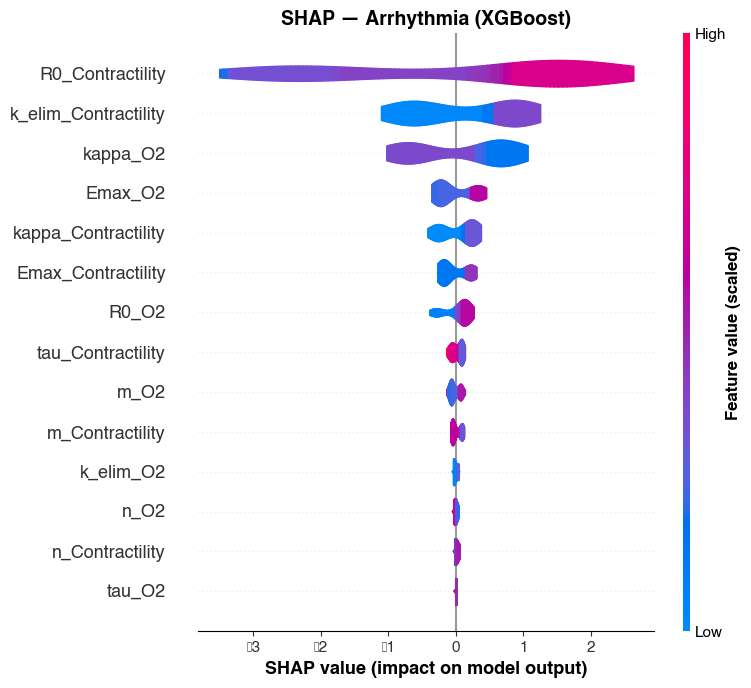

2. Plotting Heart Damage (RBF SVM)...


c:\Users\NoahB\miniconda3\envs\jupyter-ai-claude\Lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Helvetica.
  plt.tight_layout()
c:\Users\NoahB\miniconda3\envs\jupyter-ai-claude\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Helvetica.
  fig.canvas.print_figure(bytes_io, **kw)


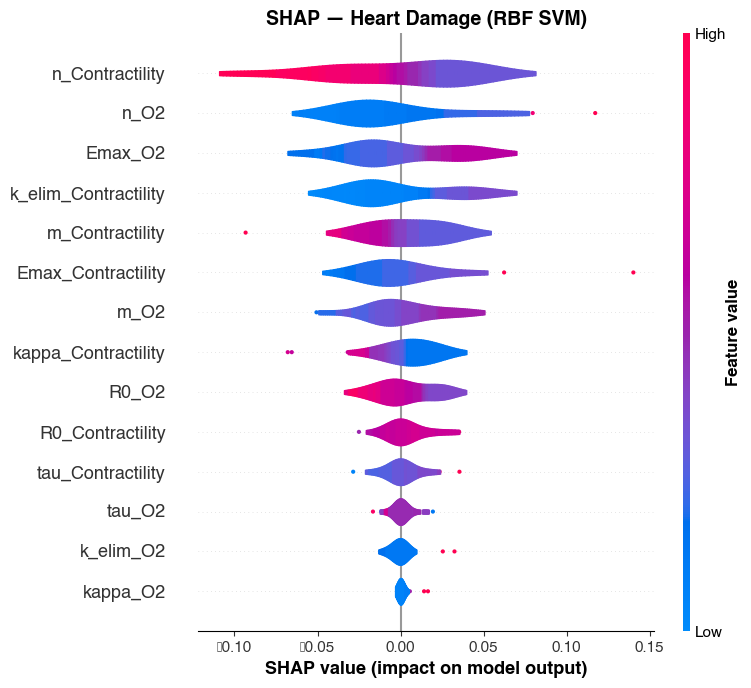

3. Plotting No Concern (Random Forest)...


c:\Users\NoahB\miniconda3\envs\jupyter-ai-claude\Lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Helvetica.
  plt.tight_layout()
c:\Users\NoahB\miniconda3\envs\jupyter-ai-claude\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Helvetica.
  fig.canvas.print_figure(bytes_io, **kw)


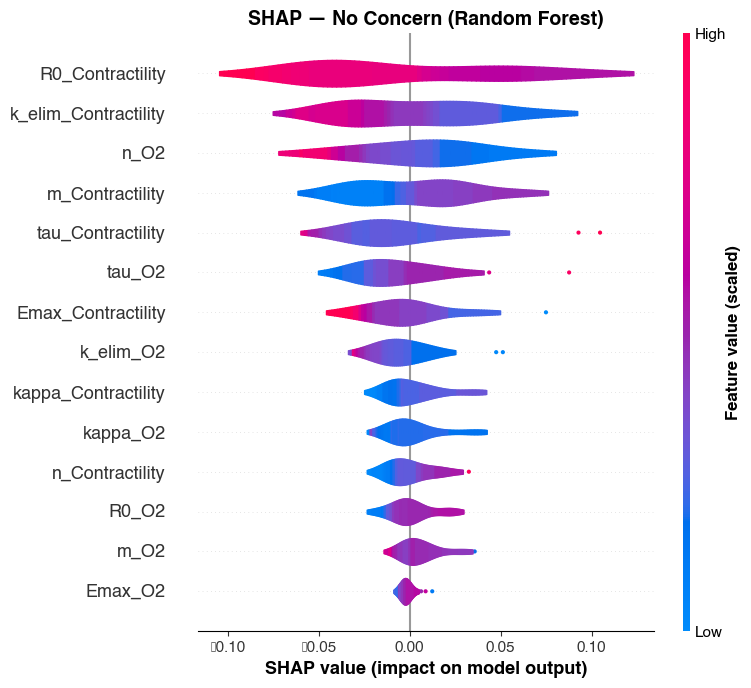

4. Plotting Less Concern (Random Forest)...


c:\Users\NoahB\miniconda3\envs\jupyter-ai-claude\Lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Helvetica.
  plt.tight_layout()
c:\Users\NoahB\miniconda3\envs\jupyter-ai-claude\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Helvetica.
  fig.canvas.print_figure(bytes_io, **kw)


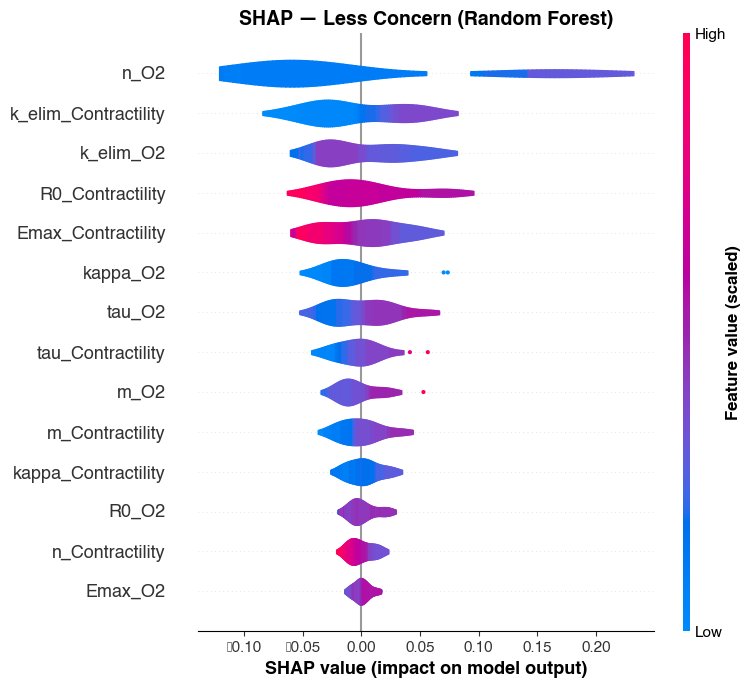

5. Plotting Most Concern (Random Forest)...


c:\Users\NoahB\miniconda3\envs\jupyter-ai-claude\Lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Helvetica.
  plt.tight_layout()
c:\Users\NoahB\miniconda3\envs\jupyter-ai-claude\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Helvetica.
  fig.canvas.print_figure(bytes_io, **kw)


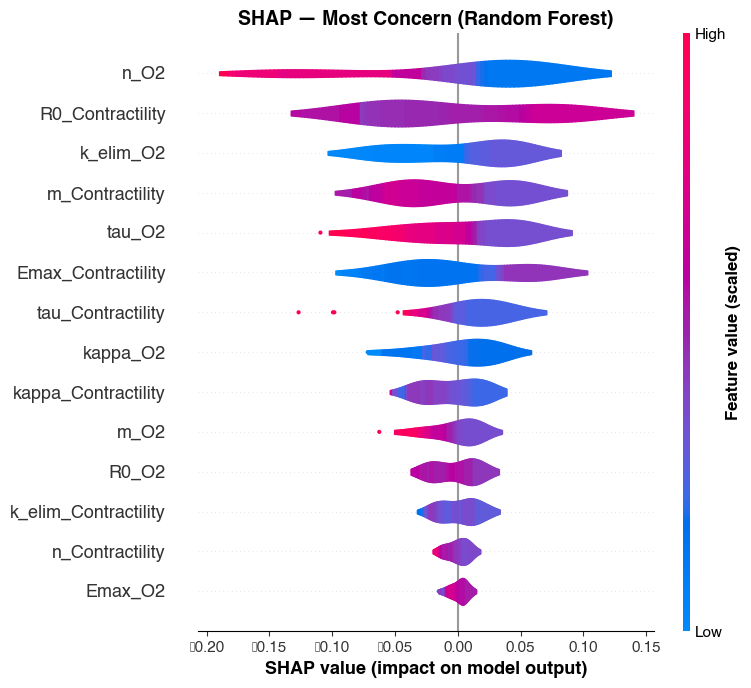


✓ All 5 SHAP plots generated.


In [30]:
# Plot SHAP Summary — 5 Separate Figures
import matplotlib.pyplot as plt

print("="*80)
print("PLOTTING SHAP SUMMARIES — ALL MODELS")
print("="*80)

cmap_shap = plt.get_cmap("coolwarm")  # blue → white → red       

# Handle SVM SHAP (might be a list)
hd_vals_for_plot = shap_values_hd[1] if isinstance(shap_values_hd, list) and len(shap_values_hd) > 1 else shap_values_hd

# ===========================
# Plot 1: Arrhythmia
# ===========================
print("\n1. Plotting Arrhythmia (XGBoost)...")
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values_arr, X_scaled_arr_df, plot_type="violin",        
    color=cmap_shap, color_bar=True, color_bar_label="Feature value (scaled)",
    show=False
)
plt.title('SHAP — Arrhythmia (XGBoost)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ===========================
# Plot 2: Heart Damage
# ===========================
print("2. Plotting Heart Damage (RBF SVM)...")
plt.figure(figsize=(12, 8))
shap.summary_plot(
    hd_vals_for_plot, features_df, plot_type="violin",
    color=cmap_shap, color_bar=True, color_bar_label="Feature value",
    show=False
)
plt.title('SHAP — Heart Damage (RBF SVM)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ===========================
# Plots 3-5: Concern Classes
# ===========================
for i, label in enumerate(["No Concern", "Less Concern", "Most Concern"]):
    print(f"{i+3}. Plotting {label} (Random Forest)...")
    plt.figure(figsize=(12, 8))
    shap.summary_plot(
        shap_values_concern[i], X_scaled_concern_df, plot_type="violin",
        color=cmap_shap, color_bar=True, color_bar_label="Feature value (scaled)",
        show=False
    )
    plt.title(f'SHAP — {label} (Random Forest)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("\n✓ All 5 SHAP plots generated.")

## Step 14: Save Data for graphs

Save the csv's of the plotted graphs to be made beautiful by danielle in prism

In [31]:
# ========================================
# Step 14: Save Data for Graphs
# ========================================
print("="*80)
print("SAVING DATA FOR EXTERNAL ANALYSIS (Graphs, Prism, etc.)")
print("="*80)

from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# ========================================
# Setup output directories
# ========================================
output_dir_cumulative = PROJECT_ROOT / 'Output' / 'Cumulative_Plot_Data'
output_dir_performance = PROJECT_ROOT / 'Output' / 'Model_Properties'
output_dir_roc = PROJECT_ROOT / 'Output' / 'ROC_Data'

output_dir_cumulative.mkdir(parents=True, exist_ok=True)
output_dir_performance.mkdir(parents=True, exist_ok=True)
output_dir_roc.mkdir(parents=True, exist_ok=True)

# ========================================
# 1. Comprehensive Model Performance Summary (with AUC)
# ========================================
print("\n1. Saving Comprehensive Model Performance Summary...")

# Arrhythmia
performance_rows = [
    {
        'Model': 'Arrhythmia',
        'Accuracy_Mean': results_arrhythmia['accuracy'],
        'Accuracy_Std': 0,
        'F1_Mean': results_arrhythmia['f1'],
        'F1_Std': 0,
        'AUC_Mean': results_arrhythmia['auc'],
        'AUC_Std': 0,
        'AUC_Fold1': results_arrhythmia['cv_auc_scores'][0],
        'AUC_Fold2': results_arrhythmia['cv_auc_scores'][1],
        'AUC_Fold3': results_arrhythmia['cv_auc_scores'][2]
    }
]

# Heart Damage
performance_rows.append({
    'Model': 'Heart Damage',
    'Accuracy_Mean': results_heart_damage['accuracy'],
    'Accuracy_Std': 0,
    'F1_Mean': results_heart_damage['f1'],
    'F1_Std': 0,
    'AUC_Mean': results_heart_damage['auc'],
    'AUC_Std': 0,
    'AUC_Fold1': results_heart_damage['cv_auc_scores'][0],
    'AUC_Fold2': results_heart_damage['cv_auc_scores'][1],
    'AUC_Fold3': results_heart_damage['cv_auc_scores'][2]
})

# Concern - Calculate macro-averaged AUC per fold
auc_concern_macro = []
for fold_idx in range(3):
    fold_auc_values = []
    for class_idx in [0, 1, 2]:
        if fold_idx < len(results_concern['per_class_auc'][class_idx]):
            auc_val = results_concern['per_class_auc'][class_idx][fold_idx]
            if not np.isnan(auc_val):
                fold_auc_values.append(auc_val)
    if fold_auc_values:
        auc_concern_macro.append(np.mean(fold_auc_values))

# Concern per-class rows
concern_class_names = ['No Concern', 'Less Concern', 'Most Concern']
for class_idx in [0, 1, 2]:
    performance_rows.append({
        'Model': concern_class_names[class_idx],
        'Accuracy_Mean': np.mean(results_concern['per_class_accuracy'][class_idx]),
        'Accuracy_Std': np.std(results_concern['per_class_accuracy'][class_idx]),
        'F1_Mean': np.mean(results_concern['per_class_f1'][class_idx]),
        'F1_Std': np.std(results_concern['per_class_f1'][class_idx]),
        'AUC_Mean': np.nanmean(results_concern['per_class_auc'][class_idx]),
        'AUC_Std': np.nanstd(results_concern['per_class_auc'][class_idx]),
        'AUC_Fold1': results_concern['per_class_auc'][class_idx][0] if len(results_concern['per_class_auc'][class_idx]) > 0 else np.nan,
        'AUC_Fold2': results_concern['per_class_auc'][class_idx][1] if len(results_concern['per_class_auc'][class_idx]) > 1 else np.nan,
        'AUC_Fold3': results_concern['per_class_auc'][class_idx][2] if len(results_concern['per_class_auc'][class_idx]) > 2 else np.nan
    })

# Concern (Overall - macro-averaged)
performance_rows.append({
    'Model': 'Concern (Overall OVR)',
    'Accuracy_Mean': np.mean([np.mean(results_concern['per_class_accuracy'][i]) for i in range(3)]),
    'Accuracy_Std': np.mean([np.std(results_concern['per_class_accuracy'][i]) for i in range(3)]),
    'F1_Mean': np.mean([np.mean(results_concern['per_class_f1'][i]) for i in range(3)]),
    'F1_Std': np.mean([np.std(results_concern['per_class_f1'][i]) for i in range(3)]),
    'AUC_Mean': np.mean(auc_concern_macro),
    'AUC_Std': np.std(auc_concern_macro),
    'AUC_Fold1': auc_concern_macro[0] if len(auc_concern_macro) > 0 else np.nan,
    'AUC_Fold2': auc_concern_macro[1] if len(auc_concern_macro) > 1 else np.nan,
    'AUC_Fold3': auc_concern_macro[2] if len(auc_concern_macro) > 2 else np.nan
})

performance_df = pd.DataFrame(performance_rows)
performance_csv_path = output_dir_performance / 'model_performance_summary.csv'
performance_df.to_csv(performance_csv_path, index=False)

print(f"✓ Comprehensive Performance Summary: {performance_csv_path}")
print("   Includes: Accuracy, F1, AUC (with means, stds, and all fold values)")
display(performance_df)

SAVING DATA FOR EXTERNAL ANALYSIS (Graphs, Prism, etc.)

1. Saving Comprehensive Model Performance Summary...
✓ Comprehensive Performance Summary: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Output\Model_Properties\model_performance_summary.csv
   Includes: Accuracy, F1, AUC (with means, stds, and all fold values)


,Model,Accuracy_Mean,Accuracy_Std,F1_Mean,F1_Std,AUC_Mean,AUC_Std,AUC_Fold1,AUC_Fold2,AUC_Fold3
0,Arrhythmia,0.759259,0.013095,0.766667,0.023570,0.820833,0.143008,0.650000,1.000000,0.812500
1,Heart Damage,0.800926,0.053592,0.888492,0.032535,0.876984,0.119970,1.000000,0.714286,0.916667
2,No Concern,0.884259,0.090958,0.333333,0.471405,0.809524,0.134687,0.714286,0.714286,1.000000
3,Less Concern,0.837963,0.062457,0.488889,0.349956,0.738095,0.204817,0.714286,1.000000,0.500000
4,Most Concern,0.722222,0.039284,0.800855,0.026177,0.883333,0.084984,0.850000,0.800000,1.000000
5,Concern (Overall OVR),0.814815,0.064233,0.541026,0.282512,0.810317,0.035969,0.759524,0.838095,0.833333


In [32]:
# Save prediction scatter data and thresholds
print('Saving prediction scatter data...')
import json
output_dir_scatter = PROJECT_ROOT / 'Output' / 'Prediction_Scatter_Data'
output_dir_scatter.mkdir(parents=True, exist_ok=True)

# Per-model prediction CSVs
arr_pred_path = output_dir_scatter / 'arrhythmia_predictions.csv'
pd.DataFrame({
    'Drug': drugs,
    'Predicted_Arrhythmia_pct': full_preds_arr,
    'Actual_Arrhythmia': df_raw['Arrhythmia'].astype(bool)
}).to_csv(arr_pred_path, index=False)

hd_pred_path = output_dir_scatter / 'heart_damage_predictions.csv'
pd.DataFrame({
    'Drug': drugs,
    'Predicted_Heart_Damage_pct': full_preds_hd,
    'Actual_Heart_Damage': df_raw['heart_damage'].astype(bool)
}).to_csv(hd_pred_path, index=False)

concern_pred_path = output_dir_scatter / 'concern_predictions.csv'
pd.DataFrame({
    'Drug': drugs,
    'Pred_No_pct': full_preds_concern[:, 0],
    'Pred_Less_pct': full_preds_concern[:, 1],
    'Pred_Most_pct': full_preds_concern[:, 2],
    'Actual_Concern': concern_actual,
    'Actual_Concern_numeric': concern_numeric
}).to_csv(concern_pred_path, index=False)

# Thresholds JSON (same ones used for the horizontal lines)
thresholds_payload = {
    'Arrhythmia_threshold_pct': thresholds.get('Arrhythmia', 0),
    'Heart_Damage_threshold_pct': thresholds.get('Heart Damage', 0),
    'Concern_thresholds_pct': concern_thresholds
}
thresholds_path = output_dir_scatter / 'prediction_thresholds.json'
thresholds_path.write_text(json.dumps(thresholds_payload, indent=2))

print('Prediction scatter data saved to:')
print(f'  - Arrhythmia: {arr_pred_path}')
print(f'  - Heart Damage: {hd_pred_path}')
print(f'  - Concern: {concern_pred_path}')
print(f'  - Thresholds JSON: {thresholds_path}')


Saving prediction scatter data...
Prediction scatter data saved to:
  - Arrhythmia: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Output\Prediction_Scatter_Data\arrhythmia_predictions.csv
  - Heart Damage: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Output\Prediction_Scatter_Data\heart_damage_predictions.csv
  - Concern: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Output\Prediction_Scatter_Data\concern_predictions.csv
  - Thresholds JSON: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Output\Prediction_Scatter_Data\prediction_thresholds.json


In [33]:
# 2. Full ROC Curve Data (FPR, TPR, ROC for each fold)
print("2. Saving Full ROC Curve Data (5 sheets, folds grouped in triples)...")
roc_excel_path = output_dir_roc / 'roc_curves_all_models.xlsx'

def write_roc_sheet(writer, sheet_name, fold_results):
    """
    fold_results: list of dicts -> [{'fpr':array, 'tpr':array, 'auc':float}, ...]
    """
    columns = []
    data = {}
    for fold_idx, fold_dict in enumerate(fold_results, start=1):
        fold_key = f'Fold{fold_idx}'
        columns.extend([
            (fold_key, 'FPR'),
            (fold_key, 'TPR'),
            (fold_key, 'ROC')
        ])
        data[(fold_key, 'FPR')] = pd.Series(fold_dict['fpr'])
        data[(fold_key, 'TPR')] = pd.Series(fold_dict['tpr'])
        roc_col = np.full(len(fold_dict['fpr']), fold_dict['auc'])
        data[(fold_key, 'ROC')] = pd.Series(roc_col)

    df = pd.DataFrame(data)
    df = df.reindex(columns=pd.MultiIndex.from_tuples(columns, names=['Fold', 'Metric']))
    df.columns = [f"{fold} - {metric}" for fold, metric in df.columns]
    df.to_excel(writer, sheet_name=sheet_name, index=False, merge_cells=False)

with pd.ExcelWriter(roc_excel_path, engine='openpyxl') as writer:
    # Arrhythmia
    print("   - Arrhythmia...")
    cv_arr = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    fold_results_arr = []
    if 'XGBOOST_AVAILABLE' in globals() and XGBOOST_AVAILABLE:
        import xgboost as xgb

    for train_idx, test_idx in cv_arr.split(features_df, arrhythmia):
        X_train, X_test = features_df.iloc[train_idx], features_df.iloc[test_idx]
        y_train = arrhythmia.iloc[train_idx] if hasattr(arrhythmia, 'iloc') else arrhythmia[train_idx]
        y_test = arrhythmia.iloc[test_idx] if hasattr(arrhythmia, 'iloc') else arrhythmia[test_idx]

        if 'XGBOOST_AVAILABLE' in globals() and XGBOOST_AVAILABLE:
            xgb_fold = xgb.XGBClassifier(
                n_estimators=150, max_depth=4, learning_rate=0.08, subsample=0.9,
                objective='binary:logistic', eval_metric='logloss',
                random_state=42, n_jobs=-1, use_label_encoder=False
            )
            pipeline_fold = Pipeline([('scaler', StandardScaler()), ('xgb', xgb_fold)])
        else:
            pipeline_fold = model_arrhythmia

        pipeline_fold.fit(X_train, y_train)
        y_pred_proba = pipeline_fold.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        fold_results_arr.append({'fpr': fpr, 'tpr': tpr, 'auc': auc(fpr, tpr)})

    write_roc_sheet(writer, 'Arrhythmia', fold_results_arr)

    # Heart Damage
    print("   - Heart Damage...")
    cv_hd = StratifiedKFold(n_splits=3, shuffle=True, random_state=21)
    fold_results_hd = []

    for train_idx, test_idx in cv_hd.split(features_df, heart_damage):
        X_train, X_test = features_df.iloc[train_idx], features_df.iloc[test_idx]
        y_train = heart_damage.iloc[train_idx] if hasattr(heart_damage, 'iloc') else heart_damage[train_idx]
        y_test = heart_damage.iloc[test_idx] if hasattr(heart_damage, 'iloc') else heart_damage[test_idx]

        svm_fold = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=40)
        pipeline_fold = Pipeline([('scaler', StandardScaler()), ('svm', svm_fold)])
        pipeline_fold.fit(X_train, y_train)

        y_scores = pipeline_fold.decision_function(X_test)
        fpr, tpr, _ = roc_curve(y_test, y_scores)
        fold_results_hd.append({'fpr': fpr, 'tpr': tpr, 'auc': auc(fpr, tpr)})

    write_roc_sheet(writer, 'HeartDamage', fold_results_hd)

    # Concern (3 classes, one-vs-rest)
    classes_concern = np.unique(concern)
    y_bin_concern = label_binarize(concern, classes=classes_concern)
    class_name_map = {0: 'No', 1: 'Less', 2: 'Most'}
    cv_concern = StratifiedKFold(n_splits=3, shuffle=True, random_state=122)

    for j, class_val in enumerate(classes_concern):
        class_label = class_name_map.get(class_val, f'Class{class_val}')
        print(f"   - Concern {class_label}...")
        fold_results_concern = []

        for train_idx, test_idx in cv_concern.split(features_df, concern):
            X_train, X_test = features_df.iloc[train_idx], features_df.iloc[test_idx]
            concern_train = concern.iloc[train_idx] if hasattr(concern, 'iloc') else concern[train_idx]

            model_concern.fit(X_train, concern_train)
            y_test_bin = y_bin_concern[test_idx, j]
            y_pred_proba = model_concern.predict_proba(X_test)[:, j]

            fpr, tpr, _ = roc_curve(y_test_bin, y_pred_proba)
            fold_results_concern.append({'fpr': fpr, 'tpr': tpr, 'auc': auc(fpr, tpr)})

        write_roc_sheet(writer, f'Concern{class_label}', fold_results_concern)

print(f"ROC Curve Data saved: {roc_excel_path}")
print("   Each sheet shows FPR/TPR/ROC columns repeated for folds 1-3.")


2. Saving Full ROC Curve Data (5 sheets, folds grouped in triples)...
   - Arrhythmia...
   - Heart Damage...
   - Concern No...


c:\Users\NoahB\miniconda3\envs\jupyter-ai-claude\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:59:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\NoahB\miniconda3\envs\jupyter-ai-claude\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:59:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\NoahB\miniconda3\envs\jupyter-ai-claude\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:59:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


   - Concern Less...
   - Concern Most...
ROC Curve Data saved: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Output\ROC_Data\roc_curves_all_models.xlsx
   Each sheet shows FPR/TPR/ROC columns repeated for folds 1-3.


In [34]:
# Save confusion matrices and classification reports to disk
print('Saving confusion matrix data...')
output_dir_confusion = PROJECT_ROOT / 'Output' / 'Confusion_Matrices'
output_dir_confusion.mkdir(parents=True, exist_ok=True)

def _save_confusion_matrix(name, cm, labels):
    df_cm = pd.DataFrame(
        cm,
        index=[f'Actual_{lbl}' for lbl in labels],
        columns=[f'Pred_{lbl}' for lbl in labels]
    )
    path_cm = output_dir_confusion / f'{name}_confusion_matrix.csv'
    df_cm.to_csv(path_cm)
    return path_cm

def _save_classification_report(name, y_true, y_pred, target_names):
    report = classification_report(
        y_true,
        y_pred,
        target_names=target_names,
        zero_division=0,
        output_dict=True
    )
    df_report = pd.DataFrame(report).T
    path_report = output_dir_confusion / f'{name}_classification_report.csv'
    df_report.to_csv(path_report)
    return path_report

paths = {}
paths['arrhythmia_cm'] = _save_confusion_matrix('arrhythmia', cm_arr, ['No', 'Yes'])
paths['heart_damage_cm'] = _save_confusion_matrix('heart_damage', cm_hd, ['No', 'Yes'])
paths['concern_cm'] = _save_confusion_matrix('concern', cm_concern, ['No Concern', 'Less Concern', 'Most Concern'])

paths['arrhythmia_report'] = _save_classification_report('arrhythmia', arr_y_true_all, arr_y_pred_all, ['No Arrhythmia', 'Arrhythmia'])
paths['heart_damage_report'] = _save_classification_report('heart_damage', hd_y_true_all, hd_y_pred_all, ['No Damage', 'Damage'])
paths['concern_report'] = _save_classification_report('concern', concern_y_true_all, concern_y_pred_all, ['No Concern', 'Less Concern', 'Most Concern'])

print('Confusion matrices and classification reports saved to:')
for label, p in paths.items():
    print(f'   - {label}: {p}')


Saving confusion matrix data...
Confusion matrices and classification reports saved to:
   - arrhythmia_cm: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Output\Confusion_Matrices\arrhythmia_confusion_matrix.csv
   - heart_damage_cm: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Output\Confusion_Matrices\heart_damage_confusion_matrix.csv
   - concern_cm: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Output\Confusion_Matrices\concern_confusion_matrix.csv
   - arrhythmia_report: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Output\Confusion_Matrices\arrhythmia_classification_report.csv
   - heart_damage_report: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Output\Confusion_Matrices\heart_damage_classification_report.csv
   - concern_report: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Output\Confusion_Matrices\concern_classification_report.csv


In [35]:
# Save All Cumulative Plot Data to CSV — Arrhythmia, Heart Damage, and Concern
print("="*80)
print("SAVING ALL CUMULATIVE PLOT DATA TO CSV")
print("="*80)

# Create output directory
output_dir = PROJECT_ROOT / 'Output' / 'Cumulative_Plot_Data'
output_dir.mkdir(parents=True, exist_ok=True)

# ========================================
# 1. Arrhythmia Cumulative Data
# ========================================
arrhythmia_pivot = plot_df_arr.pivot(
    index='Rank', 
    columns='Drug', 
    values='Arrhythmia (%)'
)
# Replace rank index with cumulative feature names
arrhythmia_pivot.index = [
    ' + '.join(top_features_arr[:r]) for r in range(1, len(arrhythmia_pivot) + 1)
]
arrhythmia_pivot.index.name = 'Cumulative_Coefficients'

arrhythmia_csv_path = output_dir / 'arrhythmia_cumulative_predictions.csv'
arrhythmia_pivot.to_csv(arrhythmia_csv_path)
print(f"\n✓ Arrhythmia: {arrhythmia_csv_path}")
print(f"  Shape: {arrhythmia_pivot.shape}")

# ========================================
# 2. Heart Damage Cumulative Data
# ========================================
heart_damage_pivot = plot_df_hd.pivot(
    index='Rank', 
    columns='Drug', 
    values='Heart Damage (%)'
)
heart_damage_pivot.index = [
    ' + '.join(top_features_hd[:r]) for r in range(1, len(heart_damage_pivot) + 1)
]
heart_damage_pivot.index.name = 'Cumulative_Coefficients'

heart_damage_csv_path = output_dir / 'heart_damage_cumulative_predictions.csv'
heart_damage_pivot.to_csv(heart_damage_csv_path)
print(f"\n✓ Heart Damage: {heart_damage_csv_path}")
print(f"  Shape: {heart_damage_pivot.shape}")

# ========================================
# 3. Concern Cumulative Data (3 classes)
# ========================================
for class_label in ['Concern: no', 'Concern: less', 'Concern: most']:
    col_name = f'{class_label} (%)'
    concern_pivot = plot_df_concern.pivot(
        index='Rank',
        columns='Drug',
        values=col_name
    )
    concern_pivot.index = [
        ' + '.join(top_features_concern[:r]) for r in range(1, len(concern_pivot) + 1)
    ]
    concern_pivot.index.name = 'Cumulative_Coefficients'
    
    # Sanitize filename
    safe_label = class_label.replace(': ', '_').replace(' ', '_')
    concern_csv_path = output_dir / f'{safe_label.lower()}_cumulative_predictions.csv'
    concern_pivot.to_csv(concern_csv_path)
    print(f"\n✓ {class_label}: {concern_csv_path}")
    print(f"  Shape: {concern_pivot.shape}")

# ========================================
# Preview
# ========================================
print("\n" + "="*80)
print("ARRHYTHMIA PREVIEW:")
print("="*80)
display(arrhythmia_pivot.head())

print("\n" + "="*80)
print("HEART DAMAGE PREVIEW:")
print("="*80)
display(heart_damage_pivot.head())

print(f"\n✓ All cumulative data saved to: {output_dir}")

SAVING ALL CUMULATIVE PLOT DATA TO CSV

✓ Arrhythmia: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Output\Cumulative_Plot_Data\arrhythmia_cumulative_predictions.csv
  Shape: (6, 25)

✓ Heart Damage: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Output\Cumulative_Plot_Data\heart_damage_cumulative_predictions.csv
  Shape: (14, 25)

✓ Concern: no: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Output\Cumulative_Plot_Data\concern_no_cumulative_predictions.csv
  Shape: (14, 25)

✓ Concern: less: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Output\Cumulative_Plot_Data\concern_less_cumulative_predictions.csv
  Shape: (14, 25)

✓ Concern: most: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Output\Cumulative_Plot_Data\concern_most_cumulative_predictions.csv
  Shape: (14, 25)

ARRHYTHMIA PREVIEW:


Drug,Amiodarone,Bortezomib,Chlorpromazine,Cobimetinib,Dactinomycin,Daunorubicin,Doxorubicin,Epirubicin,Erlotinib,Etomoxir,Gemcitibine,Ibrutinib,Ibuprofen,Isoproterenol,Mexiletine,Nifedipine,Panobinostat,Plicamycin,Rosiglitazone,Sotalol,Sunitinib,Vandetanib,Vincristine,Vioxx,Vorinostat
Cumulative_Coefficients,,,,,,,,,,,,,,,,,,,,,,,,,
R0_Contractility,57.400417,65.216507,65.216507,7.249504,16.710299,65.216507,65.216507,65.216507,7.249504,8.279935,65.216507,65.216507,7.249504,65.216507,65.216507,57.400417,54.512630,7.249504,7.249504,65.216507,16.710299,65.216507,57.400417,7.249504,7.249504
R0_Contractility + k_elim_Contractility,89.027435,91.863243,91.863243,10.056754,16.710299,65.216507,65.216507,65.216507,7.249504,10.861473,91.863243,65.216507,7.249504,91.863243,91.863243,89.027435,54.512630,7.249504,7.249504,91.863243,53.946804,91.863243,57.400417,19.845161,19.845161
R0_Contractility + k_elim_Contractility + tau_Contractility,89.027435,91.863243,91.863243,10.056754,15.758462,65.216507,65.216507,65.216507,7.249504,10.861473,91.863243,65.216507,7.249504,91.863243,91.863243,89.027435,54.512630,6.792618,7.249504,91.863243,53.946804,91.863243,55.680275,18.754972,18.754972
R0_Contractility + k_elim_Contractility + tau_Contractility + m_Contractility,87.355621,91.863243,91.863243,8.693025,13.739676,61.486237,61.486237,65.216507,6.240036,9.400025,90.577774,65.216507,6.240036,91.863243,90.577774,89.027435,54.512630,5.842761,7.249504,91.863243,49.935734,90.577774,51.684971,18.754972,16.427158
R0_Contractility + k_elim_Contractility + tau_Contractility + m_Contractility + R0_O2,92.384048,91.863243,95.197624,8.693025,17.952698,61.486237,71.033546,76.700996,6.240036,9.813196,94.406853,76.700996,6.524313,91.863243,94.406853,93.440941,67.785507,6.110118,7.576053,95.197624,57.809448,90.577774,51.684971,19.490871,17.090937



HEART DAMAGE PREVIEW:


Drug,Amiodarone,Bortezomib,Chlorpromazine,Cobimetinib,Dactinomycin,Daunorubicin,Doxorubicin,Epirubicin,Erlotinib,Etomoxir,Gemcitibine,Ibrutinib,Ibuprofen,Isoproterenol,Mexiletine,Nifedipine,Panobinostat,Plicamycin,Rosiglitazone,Sotalol,Sunitinib,Vandetanib,Vincristine,Vioxx,Vorinostat
Cumulative_Coefficients,,,,,,,,,,,,,,,,,,,,,,,,,
kappa_Contractility,87.623808,87.632271,87.607276,87.562161,87.622532,87.623942,87.622532,87.622534,87.633827,87.444337,87.471304,87.625144,87.622622,87.624830,87.484272,87.186892,87.175039,87.622544,87.424928,87.632196,87.623291,87.626391,87.622531,87.629230,87.623109
kappa_Contractility + m_Contractility,86.648510,87.606548,87.573997,87.007994,86.956841,86.907405,85.966860,87.598372,86.403626,86.118024,86.418260,87.300991,85.627909,87.318892,84.929177,87.157094,86.846839,86.823679,87.241323,87.604696,85.875297,86.643009,85.647811,87.601201,86.035486
kappa_Contractility + m_Contractility + R0_O2,81.732238,85.937874,84.072060,83.782724,82.874340,84.761424,81.843431,85.652303,82.322572,79.095981,79.874765,83.182724,80.603463,85.103877,77.760820,83.791335,83.635067,82.650594,82.546048,83.772512,80.713971,84.511343,81.646059,83.691377,81.306109
kappa_Contractility + m_Contractility + R0_O2 + n_Contractility,79.731493,85.659888,83.966501,81.632826,75.447484,82.984585,75.089368,80.004045,77.554573,77.141661,78.521029,77.506387,75.975069,84.685347,72.007014,83.618568,79.937003,75.215319,82.448666,83.673539,77.571208,84.275835,75.790761,83.534166,75.255752
kappa_Contractility + m_Contractility + R0_O2 + n_Contractility + m_O2,77.990651,86.024391,83.158119,80.209250,74.115508,83.012567,73.789435,79.897910,76.006616,71.819064,74.349752,78.535000,75.206487,85.311239,67.636378,82.848311,77.986293,73.791419,82.196630,82.489250,75.986936,84.079744,76.848085,82.334491,77.518077



✓ All cumulative data saved to: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Output\Cumulative_Plot_Data


In [36]:
# Cell 15: Save All Important Features to CSV
# Depends on: Cell 17 (Arrhythmia model), Cell 20 (Heart Damage model), Cell 22 (Concern model), Cell 27 (Feature Importance Summary)

print("="*80)
print("SAVING ALL IMPORTANT FEATURES TO CSV")
print("="*80)

from sklearn.inspection import permutation_importance

# Collect feature importances from all models
all_features_list = []

# 1. Arrhythmia (XGBoost) - has feature importances
print("\n1. Collecting Arrhythmia (XGBoost) feature importances...")
arrhythmia_importances = results_arrhythmia['feature_importances'].copy()
arrhythmia_importances['Model'] = 'Arrhythmia'
all_features_list.append(arrhythmia_importances[['Model', 'Feature', 'Importance']])

# 2. Heart Damage (Gaussian Kernel SVM) - calculate permutation importance
print("2. Calculating Heart Damage (Gaussian Kernel) permutation importance...")
perm_heart_damage = permutation_importance(
    model_heart_damage,
    features_df,
    heart_damage,
    scoring='roc_auc',
    n_repeats=200,
    random_state=42,
    n_jobs=-1
)
heart_damage_importances = pd.DataFrame({
    'Feature': features_df.columns,
    'Importance': perm_heart_damage.importances_mean
}).sort_values('Importance', ascending=False)
heart_damage_importances['Model'] = 'Heart Damage'
all_features_list.append(heart_damage_importances[['Model', 'Feature', 'Importance']])

# 3. Concern (Random Forest) - has feature importances
print("3. Collecting Concern (Random Forest) feature importances...")
concern_importances = results_concern['feature_importances'].copy()
concern_importances['Model'] = 'Concern'
all_features_list.append(concern_importances[['Model', 'Feature', 'Importance']])

# Combine all features into a single DataFrame
all_features_df = pd.concat(all_features_list, ignore_index=True)

# Reorder columns: Model, Feature, Importance
all_features_df = all_features_df[['Model', 'Feature', 'Importance']]

# Save to CSV
output_dir = PROJECT_ROOT / 'Output' / 'Model_Properties'
output_dir.mkdir(parents=True, exist_ok=True)

csv_path = output_dir / 'all_models_important_features.csv'
all_features_df.to_csv(csv_path, index=False)

print(f"\n✓ Saved all important features to: {csv_path}")
print(f"\nTotal features saved: {len(all_features_df)}")
print(f"  - Arrhythmia: {len(arrhythmia_importances)} features")
print(f"  - Heart Damage: {len(heart_damage_importances)} features")
print(f"  - Concern: {len(concern_importances)} features")

print(f"\nFirst few rows of saved CSV:")
display(all_features_df.head(10))


SAVING ALL IMPORTANT FEATURES TO CSV

1. Collecting Arrhythmia (XGBoost) feature importances...
2. Calculating Heart Damage (Gaussian Kernel) permutation importance...
3. Collecting Concern (Random Forest) feature importances...

✓ Saved all important features to: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Output\Model_Properties\all_models_important_features.csv

Total features saved: 42
  - Arrhythmia: 14 features
  - Heart Damage: 14 features
  - Concern: 14 features

First few rows of saved CSV:


,Model,Feature,Importance
0,Arrhythmia,R0_Contractility,0.269799
1,Arrhythmia,k_elim_Contractility,0.104979
2,Arrhythmia,tau_Contractility,0.103587
3,Arrhythmia,m_Contractility,0.099338
4,Arrhythmia,R0_O2,0.094837
5,Arrhythmia,n_O2,0.074466
6,Arrhythmia,kappa_Contractility,0.050019
7,Arrhythmia,kappa_O2,0.047848
8,Arrhythmia,Emax_O2,0.046190
9,Arrhythmia,m_O2,0.041327


In [37]:
# Save SHAP Values Data to CSV for Prism Plotting
print("="*80)
print("SAVING SHAP VALUES DATA TO CSV")
print("="*80)

import numpy as np
import pandas as pd

# Create output directory
output_dir = PROJECT_ROOT / 'Output' / 'SHAP_Data'
output_dir.mkdir(parents=True, exist_ok=True)

# ========================================
# 1. Arrhythmia SHAP Values
# ========================================
print("\n1. Saving Arrhythmia SHAP values...")

# SHAP values matrix (samples × features)
shap_arr_df = pd.DataFrame(
    shap_values_arr,
    columns=features_df.columns,
    index=df_raw['Drug'].values
)
shap_arr_df.index.name = 'Drug'

shap_arr_path = output_dir / 'shap_arrhythmia_values.csv'
shap_arr_df.to_csv(shap_arr_path)
print(f"  ✓ SHAP values: {shap_arr_path}")

# Mean |SHAP| importance
mean_shap_arr = pd.DataFrame({
    'Feature': features_df.columns,
    'Mean_Abs_SHAP': np.abs(shap_values_arr).mean(axis=0)
}).sort_values('Mean_Abs_SHAP', ascending=False)
mean_shap_arr_path = output_dir / 'shap_arrhythmia_mean_importance.csv'
mean_shap_arr.to_csv(mean_shap_arr_path, index=False)
print(f"  ✓ Mean |SHAP|: {mean_shap_arr_path}")

# ========================================
# 2. Heart Damage SHAP Values
# ========================================
print("\n2. Saving Heart Damage SHAP values...")

shap_hd_df = pd.DataFrame(
    shap_values_hd,
    columns=features_df.columns,
    index=df_raw['Drug'].values
)
shap_hd_df.index.name = 'Drug'

shap_hd_path = output_dir / 'shap_heart_damage_values.csv'
shap_hd_df.to_csv(shap_hd_path)
print(f"  ✓ SHAP values: {shap_hd_path}")

# Mean |SHAP| importance
mean_shap_hd = pd.DataFrame({
    'Feature': features_df.columns,
    'Mean_Abs_SHAP': np.abs(shap_values_hd).mean(axis=0)
}).sort_values('Mean_Abs_SHAP', ascending=False)
mean_shap_hd_path = output_dir / 'shap_heart_damage_mean_importance.csv'
mean_shap_hd.to_csv(mean_shap_hd_path, index=False)
print(f"  ✓ Mean |SHAP|: {mean_shap_hd_path}")

# ========================================
# 3. Concern SHAP Values (3 classes)
# ========================================
print("\n3. Saving Concern SHAP values (3 classes)...")

concern_class_names = ['no_concern', 'less_concern', 'most_concern']

for class_idx, class_name in enumerate(concern_class_names):
    # SHAP values for this class
    shap_concern_class_df = pd.DataFrame(
        shap_values_concern[class_idx],
        columns=features_df.columns,
        index=df_raw['Drug'].values
    )
    shap_concern_class_df.index.name = 'Drug'
    
    shap_concern_path = output_dir / f'shap_concern_{class_name}_values.csv'
    shap_concern_class_df.to_csv(shap_concern_path)
    print(f"  ✓ {class_name} SHAP values: {shap_concern_path}")
    
    # Mean |SHAP| importance for this class
    mean_shap_concern = pd.DataFrame({
        'Feature': features_df.columns,
        'Mean_Abs_SHAP': np.abs(shap_values_concern[class_idx]).mean(axis=0)
    }).sort_values('Mean_Abs_SHAP', ascending=False)
    mean_shap_concern_path = output_dir / f'shap_concern_{class_name}_mean_importance.csv'
    mean_shap_concern.to_csv(mean_shap_concern_path, index=False)
    print(f"  ✓ {class_name} Mean |SHAP|: {mean_shap_concern_path}")

# ========================================
# 4. Feature Values (for color scale reference)
# ========================================
print("\n4. Saving feature values (for SHAP color scale)...")

# Scaled features (used for Arrhythmia and Concern)
scaled_features_df = pd.DataFrame(
    X_scaled_arr,
    columns=features_df.columns,
    index=df_raw['Drug'].values
)
scaled_features_df.index.name = 'Drug'
scaled_features_path = output_dir / 'feature_values_scaled.csv'
scaled_features_df.to_csv(scaled_features_path)
print(f"  ✓ Scaled features: {scaled_features_path}")

# Raw features (used for Heart Damage KernelSHAP)
raw_features_df = features_df.copy()
raw_features_df.index = df_raw['Drug'].values
raw_features_df.index.name = 'Drug'
raw_features_path = output_dir / 'feature_values_raw.csv'
raw_features_df.to_csv(raw_features_path)
print(f"  ✓ Raw features: {raw_features_path}")

# ========================================
# 5. Combined Summary Table
# ========================================
print("\n5. Creating combined SHAP importance summary...")

summary_rows = []

# Arrhythmia
for _, row in mean_shap_arr.iterrows():
    summary_rows.append({
        'Model': 'Arrhythmia',
        'Feature': row['Feature'],
        'Mean_Abs_SHAP': row['Mean_Abs_SHAP']
    })

# Heart Damage
for _, row in mean_shap_hd.iterrows():
    summary_rows.append({
        'Model': 'Heart Damage',
        'Feature': row['Feature'],
        'Mean_Abs_SHAP': row['Mean_Abs_SHAP']
    })

# Concern (all 3 classes)
for class_idx, class_label in enumerate(['No Concern', 'Less Concern', 'Most Concern']):
    mean_abs = np.abs(shap_values_concern[class_idx]).mean(axis=0)
    for feat_idx, feat_name in enumerate(features_df.columns):
        summary_rows.append({
            'Model': class_label,
            'Feature': feat_name,
            'Mean_Abs_SHAP': mean_abs[feat_idx]
        })

shap_summary_df = pd.DataFrame(summary_rows)
shap_summary_path = output_dir / 'shap_all_models_summary.csv'
shap_summary_df.to_csv(shap_summary_path, index=False)
print(f"  ✓ Combined summary: {shap_summary_path}")

# ========================================
# Summary
# ========================================
print("\n" + "="*80)
print("ALL SHAP DATA SAVED")
print("="*80)
print(f"Output directory: {output_dir}")
print("\nSaved files:")
print("  Arrhythmia:")
print(f"    - shap_arrhythmia_values.csv ({shap_arr_df.shape})")
print(f"    - shap_arrhythmia_mean_importance.csv")
print("  Heart Damage:")
print(f"    - shap_heart_damage_values.csv ({shap_hd_df.shape})")
print(f"    - shap_heart_damage_mean_importance.csv")
print("  Concern (3 classes):")
for class_name in concern_class_names:
    print(f"    - shap_concern_{class_name}_values.csv")
    print(f"    - shap_concern_{class_name}_mean_importance.csv")
print("  Feature values:")
print(f"    - feature_values_scaled.csv")
print(f"    - feature_values_raw.csv")
print("  Summary:")
print(f"    - shap_all_models_summary.csv")

print("\n✓ All SHAP data saved for Prism plotting.")

SAVING SHAP VALUES DATA TO CSV

1. Saving Arrhythmia SHAP values...
  ✓ SHAP values: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Output\SHAP_Data\shap_arrhythmia_values.csv
  ✓ Mean |SHAP|: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Output\SHAP_Data\shap_arrhythmia_mean_importance.csv

2. Saving Heart Damage SHAP values...
  ✓ SHAP values: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Output\SHAP_Data\shap_heart_damage_values.csv
  ✓ Mean |SHAP|: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Output\SHAP_Data\shap_heart_damage_mean_importance.csv

3. Saving Concern SHAP values (3 classes)...
  ✓ no_concern SHAP values: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Output\SHAP_Data\shap_concern_no_concern_values.csv
  ✓ no_concern Mean |SHAP|: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Output\SHAP_Data\shap_concern_no_concern_mean_importance.csv
  ✓ less_concern SHAP values: c:\Users\N

## Step 15: Save Models (Optional)

Save the trained models and feature importance DataFrames for later use.


In [32]:
# Cell 15: Save Models (Optional)
import joblib

# Create output directory
output_dir = PROJECT_ROOT / 'Output' / 'Model_Properties'
output_dir.mkdir(parents=True, exist_ok=True)

print("="*80)
print("SAVING TRAINED MODELS")
print("="*80)

# Save models
model_paths = {}

# Arrhythmia (XGBoost)
arrhythmia_path = output_dir / 'xgb_pkpd_elimination_Arrhythmia.joblib'
joblib.dump(model_arrhythmia, arrhythmia_path)
model_paths['Arrhythmia'] = arrhythmia_path
print(f"  ✓ Arrhythmia: {arrhythmia_path.name}")

# Heart Damage (SVM RBF)
heart_damage_path = output_dir / 'svm_rbf_pkpd_elimination_Heart_Damage.joblib'
joblib.dump(model_heart_damage, heart_damage_path)
model_paths['Heart_Damage'] = heart_damage_path
print(f"  ✓ Heart Damage: {heart_damage_path.name}")

# Concern (Random Forest)
concern_path = output_dir / 'random_forest_pkpd_elimination_Concern.joblib'
joblib.dump(model_concern, concern_path)
model_paths['Concern'] = concern_path
print(f"  ✓ Concern: {concern_path.name}")

print(f"\n✓ All models saved to: {output_dir}")

SAVING TRAINED MODELS
  ✓ Arrhythmia: xgb_pkpd_elimination_Arrhythmia.joblib
  ✓ Heart Damage: svm_rbf_pkpd_elimination_Heart_Damage.joblib
  ✓ Concern: random_forest_pkpd_elimination_Concern.joblib

✓ All models saved to: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Output\Model_Properties
